In [39]:
"""
06_analysis_crosscompany.py
────────────────────────────
Lädt corpus.parquet, berechnet Frequenzen und erstellt 4 Plots.
Voraussetzung: 05_extraction.py wurde ausgeführt.

Ausführen: python 06_analysis_crosscompany.py
"""

'\n06_analysis_crosscompany.py\n────────────────────────────\nLädt corpus.parquet, berechnet Frequenzen und erstellt 4 Plots.\nVoraussetzung: 05_extraction.py wurde ausgeführt.\n\nAusführen: python 06_analysis_crosscompany.py\n'

In [40]:
# ════════════════════════════════════════════════════════════════════════════
# KONFIGURATION — hier alle Parameter anpassen
# ════════════════════════════════════════════════════════════════════════════
import re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore')

In [41]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 150,
    'figure.facecolor': 'white',
})

In [42]:
# ── Pfade ──
PROJECT_ROOT = Path('/Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis')
CORPUS_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'corpus.parquet'
FIG_DIR      = PROJECT_ROOT / 'outputs' / 'figures' / 'cross_company'
REP_DIR      = PROJECT_ROOT / 'outputs' / 'reports'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REP_DIR.mkdir(parents=True, exist_ok=True)

In [43]:
# ── Analysejahre ──
YEARS = [2022, 2023, 2024, 2025]

In [47]:
# ── Schlagwortgruppen (Groß-/Kleinschreibung wird ignoriert) ──
TERMS = {
    'KI/AI': [
        'ki', 'ai',
        'künstliche intelligenz',
        'artificial intelligence',
        'generative ai', 'generative ki',
        'machine learning', 'deep learning',
        'large language model', 'llm', 'GenAI',
    ],
    'Daten/Data': [
        'daten', 'data',
        'datengetrieben', 'data-driven', 'data driven',
        'datenarchitektur', 'data architecture',
    ],
}
GROUPS = list(TERMS.keys())

In [48]:
# ── Farben ──
C = {
    'KI/AI':      '#1A5F9E',
    'Daten/Data': '#D95F2B',
    'ceo':        '#1A5F9E',
    'ar':         '#D95F2B',
}

In [49]:
NORM_FACTOR = 1000

In [50]:
print('✓ Konfiguration geladen')
print(f'  KI/AI-Terme     : {TERMS["KI/AI"]}')
print(f'  Daten/Data-Terme: {TERMS["Daten/Data"]}')

✓ Konfiguration geladen
  KI/AI-Terme     : ['ki', 'ai', 'künstliche intelligenz', 'artificial intelligence', 'generative ai', 'generative ki', 'machine learning', 'deep learning', 'large language model', 'llm', 'GenAI']
  Daten/Data-Terme: ['daten', 'data', 'datengetrieben', 'data-driven', 'data driven', 'datenarchitektur', 'data architecture']


In [51]:
# ════════════════════════════════════════════════════════════════════════════
# DATEN LADEN & FREQUENZEN BERECHNEN
# Alle Plot-Funktionen lesen aus `freq` und `agg`
# ════════════════════════════════════════════════════════════════════════════
def count_term(text, term):
    if not text:
        return 0
    return len(re.findall(r'\b' + re.escape(term) + r'\b', text, re.IGNORECASE))

In [52]:
corpus = pd.read_parquet(CORPUS_PATH)
corpus = corpus[corpus['year'].isin(YEARS)].copy()
print(f'\nCorpus: {len(corpus)} Dokumente | {corpus["company"].nunique()} Firmen')


Corpus: 240 Dokumente | 36 Firmen


In [53]:
rows = []
for _, doc in corpus.iterrows():
    for group, terms in TERMS.items():
        raw  = sum(count_term(doc['text'], t) for t in terms)
        norm = (raw / doc['wordcount']) * NORM_FACTOR if doc['wordcount'] > 0 else 0
        rows.append({
            'company':    doc['company'],
            'sector':     doc['sector'],
            'year':       doc['year'],
            'role':       doc['role'],
            'language':   doc['language'],
            'wordcount':  doc['wordcount'],
            'group':      group,
            'count_raw':  raw,
            'count_norm': round(norm, 4),
        })

In [54]:
freq = pd.DataFrame(rows)

In [55]:
agg = freq.groupby(['company', 'sector', 'year', 'group']).agg(
    count_raw=('count_raw', 'sum'),
    count_norm=('count_norm', 'mean'),
    wordcount=('wordcount', 'sum'),
).reset_index()

In [56]:
import sys
print(sys.executable)
print(sys.version)
import pandas as pd
print(pd.__version__)

/Users/tgumpp/Documents/MasterThesis/venv/bin/python
3.9.12 (main, Apr  5 2022, 01:53:17) 
[Clang 12.0.0 ]
2.3.3


In [57]:
freq.to_csv(REP_DIR / 'freq_detail.csv',     index=False, encoding='utf-8-sig')
agg.to_csv(REP_DIR  / 'freq_aggregated.csv', index=False, encoding='utf-8-sig')
print('✓ freq_detail.csv & freq_aggregated.csv exportiert')

✓ freq_detail.csv & freq_aggregated.csv exportiert


In [58]:
# ════════════════════════════════════════════════════════════════════════════
# STUPIDITY CHECK 2: KWIC für Daten/Data
# ════════════════════════════════════════════════════════════════════════════
def kwic_check(corpus, terms, company=None, year=None, window_sentences=1):
    """
    Gibt alle Vorkommen der Terms im Satzkontext aus.
    window_sentences=1 → den ganzen Satz in dem der Treffer liegt.
    """
    subset = corpus.copy()
    if company:
        subset = subset[subset['company'] == company]
    if year:
        subset = subset[subset['year'] == year]

    results = []
    for _, doc in subset.iterrows():
        # Text in Sätze aufteilen
        sentences = re.split(r'(?<=[.!?])\s+', doc['text'])
        for sent in sentences:
            for term in terms:
                pattern = r'\b' + re.escape(term) + r'\b'
                if re.search(pattern, sent, re.IGNORECASE):
                    # Treffer im Satz markieren
                    marked = re.sub(
                        pattern,
                        lambda m: f'>>>{m.group()}<<<',
                        sent,
                        flags=re.IGNORECASE
                    )
                    results.append({
                        'company': doc['company'],
                        'year':    doc['year'],
                        'role':    doc['role'],
                        'term':    term,
                        'context': marked.strip(),
                    })

    df = pd.DataFrame(results)
    return df

In [59]:
# Ausführen — alle Daten/Data-Treffer ausgeben
daten_kwic = kwic_check(
    corpus,
    terms=TERMS['Daten/Data'],
    # company='SAP',   # optional: auf eine Firma einschränken
    # year=2024,       # optional: auf ein Jahr einschränken
)

In [60]:
print(f'\nDaten/Data-Treffer gesamt: {len(daten_kwic)}')
print(f'Davon verdächtig kurze Kontexte (< 20 Zeichen):')
short = daten_kwic[daten_kwic['context'].str.len() < 40]
print(short[['company','year','role','context']].to_string(index=False))


Daten/Data-Treffer gesamt: 200
Davon verdächtig kurze Kontexte (< 20 Zeichen):
       company  year role                                 context
       Allianz  2024  ceo     Teilweise fehlen\n>>>Daten<<< ganz.
           BMW  2024  ceo    Mittels KI und >>>Data<<< Analytics.
      Brenntag  2025   ar          >>>Data<<<.Excellence (DiDEX).
   Continental  2023  ceo           Und >>>Daten<<< zu entwenden.
DeutscheBoerse  2022  ceo         Märkte produzieren >>>Daten<<<.
DeutscheBoerse  2022  ceo             >>>Daten<<< bewegen Märkte.
DeutscheBoerse  2022  ceo    Die >>>Daten<<< sprechen da für uns.
           Eon  2023  ceo               Die >>>Daten<<< sicherer.
     Fresenius  2024  ceo                            >>>Daten<<<.
     Fresenius  2024  ceo            Sie basiert auf >>>Daten<<<.
    HannoverRe  2022  ceo                   Und ihre >>>Daten<<<.
           SAP  2024  ceo  Und wir harmonisieren die >>>Daten<<<.
       Siemens  2023  ceo           Sensoren sammeln >>>Daten<

In [61]:
# Export zur manuellen Durchsicht
daten_kwic.to_csv(
    REP_DIR / 'kwic_daten_check.csv',
    index=False,
    encoding='utf-8-sig'
)
print(f'\n✓ Alle Treffer exportiert nach: {REP_DIR}/kwic_daten_check.csv')


✓ Alle Treffer exportiert nach: /Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis/outputs/reports/kwic_daten_check.csv


## Plot 1 — Zeitverlauf: y1 = norm, y2 = Gesamtsumme

  ✓ plot1_zeitverlauf_dual_axis.png


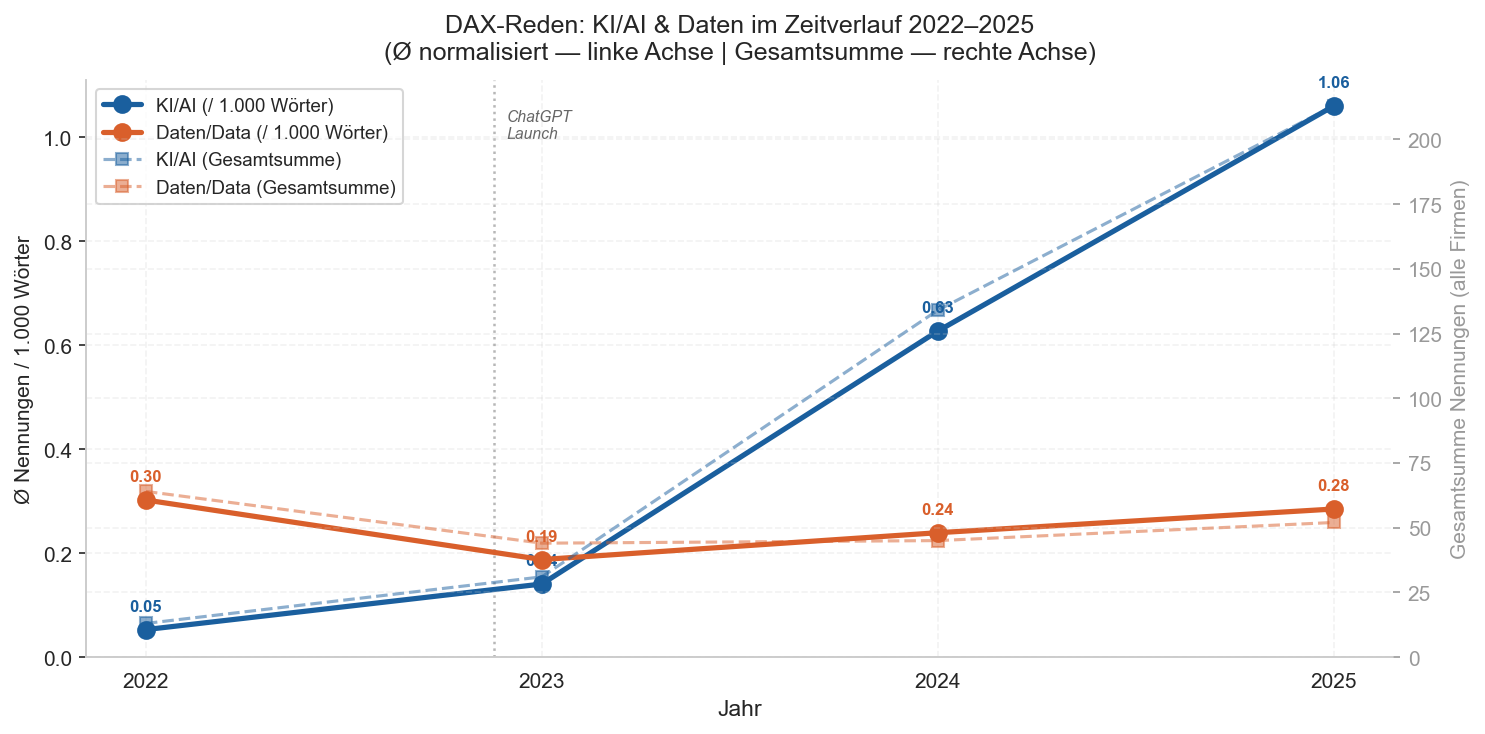

In [63]:
yearly = agg.groupby(['year', 'group']).agg(
    norm_mean=('count_norm', 'mean'),
    raw_sum=('count_raw', 'sum'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

for group in GROUPS:
    sub   = yearly[yearly['group'] == group].sort_values('year')
    color = C[group]
    ax1.plot(sub['year'], sub['norm_mean'], marker='o', linewidth=2.5,
             markersize=8, color=color, label=f'{group} (/ 1.000 Wörter)', zorder=3)
    ax2.plot(sub['year'], sub['raw_sum'], marker='s', linewidth=1.5,
             markersize=6, color=color, linestyle='--', alpha=0.5,
             label=f'{group} (Gesamtsumme)', zorder=2)
    for _, row in sub.iterrows():
        ax1.annotate(f"{row['norm_mean']:.2f}",
                     (row['year'], row['norm_mean']),
                     xytext=(0, 9), textcoords='offset points',
                     ha='center', fontsize=8, color=color, fontweight='bold')

ax1.axvline(x=2022.88, color='#999', linestyle=':', linewidth=1.2, alpha=0.7)
ax1.text(2022.91, ax1.get_ylim()[1] * 0.95,
         'ChatGPT\nLaunch', fontsize=7.5, color='#666', style='italic', va='top')

ax1.set_xticks(YEARS)
ax1.set_xlabel('Jahr', fontsize=11)
ax1.set_ylabel('Ø Nennungen / 1.000 Wörter', fontsize=10)
ax2.set_ylabel('Gesamtsumme Nennungen (alle Firmen)', fontsize=10, color='#999')
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis='y', colors='#999')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(
    'DAX-Reden: KI/AI & Daten im Zeitverlauf 2022–2025\n'
    '(Ø normalisiert — linke Achse | Gesamtsumme — rechte Achse)',
    fontsize=12, pad=10
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot1_zeitverlauf_dual_axis.png', bbox_inches='tight')
print('  ✓ plot1_zeitverlauf_dual_axis.png')
plt.show()

## Plot 1 (CEO only)

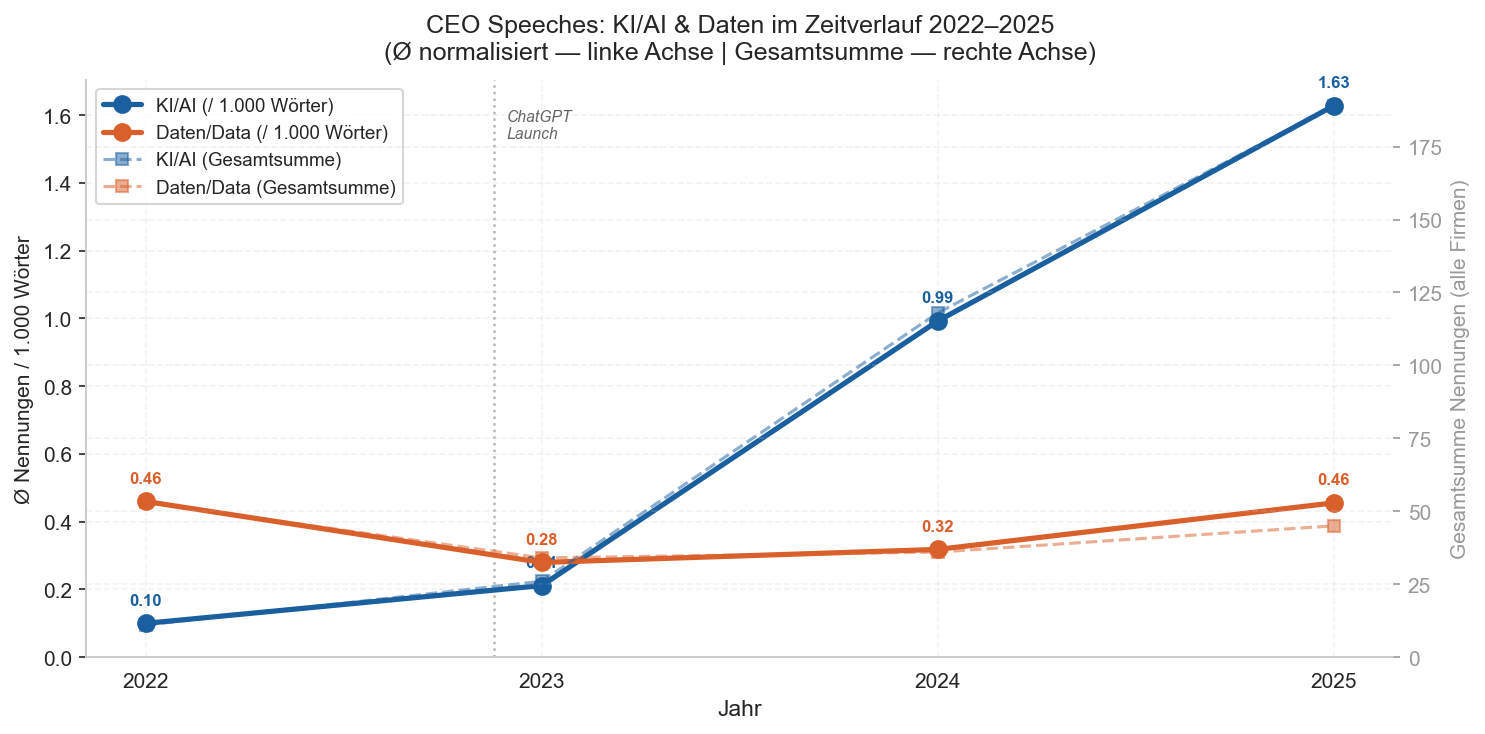

In [88]:
# ── PLOT 1 CEO ONLY: Zeitverlauf y1=norm, y2=Summe ───────────────────────────

yearly_ceo = freq[freq['role'] == 'ceo'].groupby(['year', 'group']).agg(
    norm_mean=('count_norm', 'mean'),
    raw_sum=('count_raw',   'sum'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

for group in GROUPS:
    sub   = yearly_ceo[yearly_ceo['group'] == group].sort_values('year')
    color = C[group]
    ax1.plot(sub['year'], sub['norm_mean'], marker='o', linewidth=2.5,
             markersize=8, color=color, label=f'{group} (/ 1.000 Wörter)', zorder=3)
    ax2.plot(sub['year'], sub['raw_sum'], marker='s', linewidth=1.5,
             markersize=6, color=color, linestyle='--', alpha=0.5,
             label=f'{group} (Gesamtsumme)', zorder=2)
    for _, row in sub.iterrows():
        ax1.annotate(f"{row['norm_mean']:.2f}",
                     (row['year'], row['norm_mean']),
                     xytext=(0, 9), textcoords='offset points',
                     ha='center', fontsize=8, color=color, fontweight='bold')

ax1.axvline(x=2022.88, color='#999', linestyle=':', linewidth=1.2, alpha=0.7)
ax1.text(2022.91, ax1.get_ylim()[1] * 0.95,
         'ChatGPT\nLaunch', fontsize=7.5, color='#666', style='italic', va='top')

ax1.set_xticks(YEARS)
ax1.set_xlabel('Jahr', fontsize=11)
ax1.set_ylabel('Ø Nennungen / 1.000 Wörter', fontsize=10)
ax2.set_ylabel('Gesamtsumme Nennungen (alle Firmen)', fontsize=10, color='#999')
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis='y', colors='#999')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x)}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title('CEO Speeches: KI/AI & Daten im Zeitverlauf 2022–2025\n'
              '(Ø normalisiert — linke Achse | Gesamtsumme — rechte Achse)',
              fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot1_zeitverlauf_ceo_only.png', bbox_inches='tight')
plt.show()

# Plot 2 — KI vs. Daten: gestapelte Balken (absolut + prozentual)

  ✓ plot2_ki_vs_daten_gestapelt.png


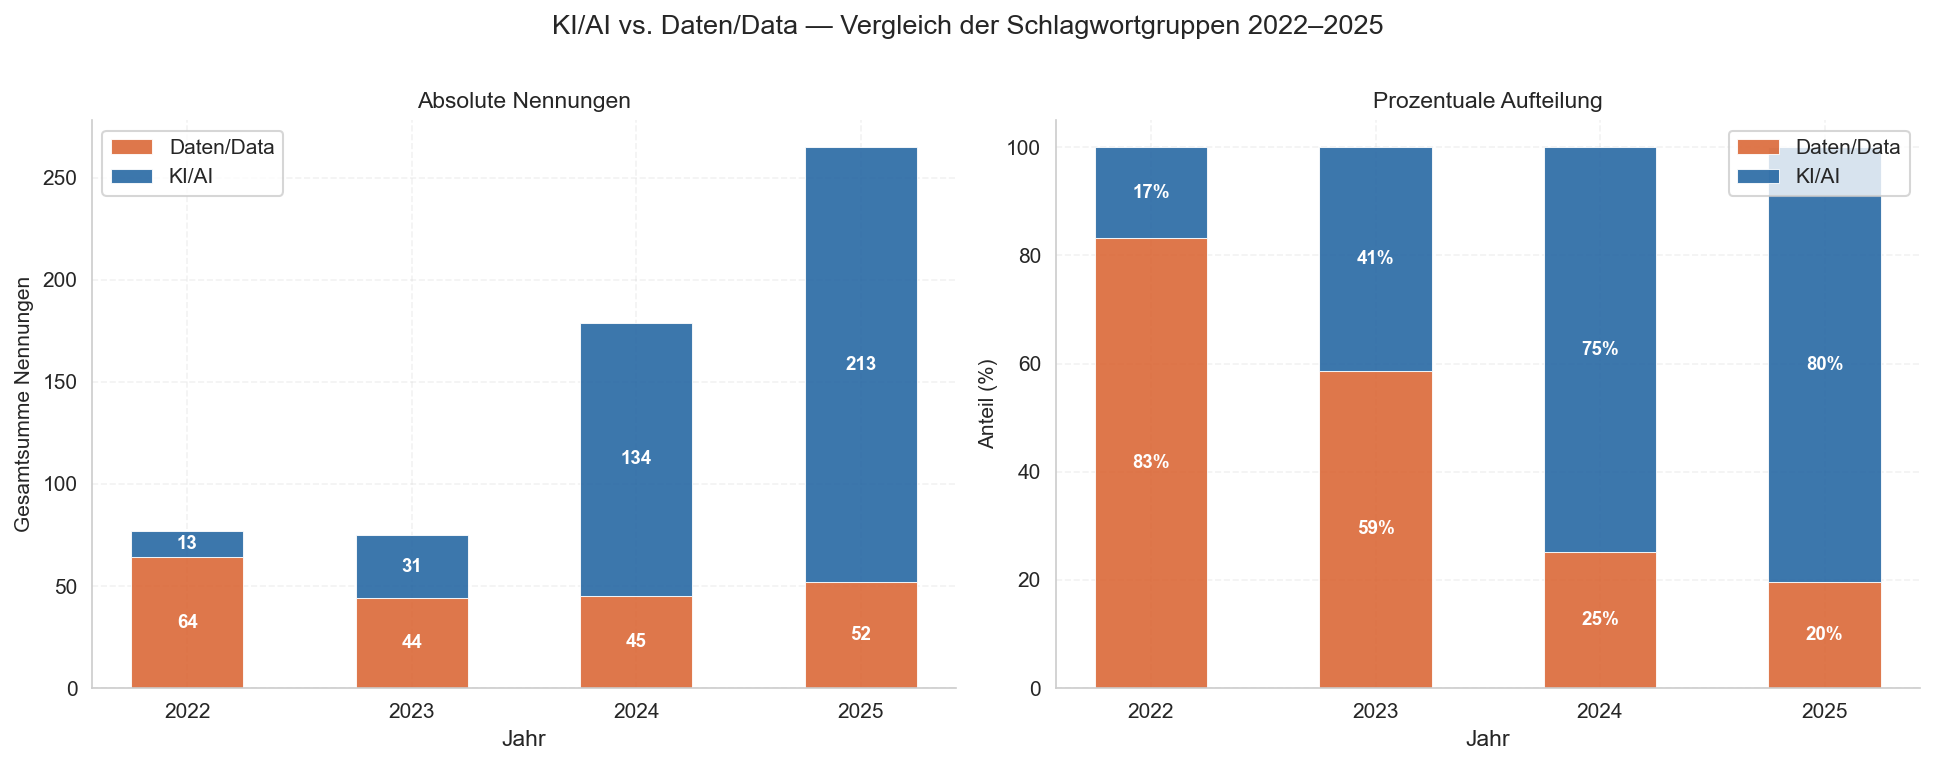

In [65]:
pivot_raw = yearly.pivot_table(
    index='year', columns='group', values='raw_sum', fill_value=0
)
pivot_raw['total'] = pivot_raw.sum(axis=1)
for g in GROUPS:
    pivot_raw[f'{g}_pct'] = pivot_raw[g] / pivot_raw['total'] * 100

fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('KI/AI vs. Daten/Data — Vergleich der Schlagwortgruppen 2022–2025',
             fontsize=13, y=1.01)

x = np.arange(len(YEARS))
bar_w = 0.5

# Absolut
bottom = np.zeros(len(YEARS))
for group in ['Daten/Data', 'KI/AI']:
    vals = [pivot_raw.loc[y, group] for y in YEARS]
    bars = ax_abs.bar(x, vals, bar_w, bottom=bottom,
                      label=group, color=C[group], alpha=0.85,
                      edgecolor='white', linewidth=0.5)
    for rect, v, b in zip(bars, vals, bottom):
        if v > 5:
            ax_abs.text(rect.get_x() + rect.get_width() / 2,
                        b + v / 2, str(int(v)),
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
    bottom += np.array(vals)

ax_abs.set_xticks(x)
ax_abs.set_xticklabels(YEARS)
ax_abs.set_xlabel('Jahr', fontsize=11)
ax_abs.set_ylabel('Gesamtsumme Nennungen', fontsize=10)
ax_abs.set_title('Absolute Nennungen', fontsize=11)
ax_abs.legend(fontsize=10)

# Prozentual
bottom_pct = np.zeros(len(YEARS))
for group in ['Daten/Data', 'KI/AI']:
    pct_vals = [pivot_raw.loc[y, f'{group}_pct'] for y in YEARS]
    bars = ax_pct.bar(x, pct_vals, bar_w, bottom=bottom_pct,
                      label=group, color=C[group], alpha=0.85,
                      edgecolor='white', linewidth=0.5)
    for rect, v, b in zip(bars, pct_vals, bottom_pct):
        if v > 3:
            ax_pct.text(rect.get_x() + rect.get_width() / 2,
                        b + v / 2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
    bottom_pct += np.array(pct_vals)

ax_pct.set_xticks(x)
ax_pct.set_xticklabels(YEARS)
ax_pct.set_xlabel('Jahr', fontsize=11)
ax_pct.set_ylabel('Anteil (%)', fontsize=10)
ax_pct.set_title('Prozentuale Aufteilung', fontsize=11)
ax_pct.set_ylim(0, 105)
ax_pct.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot2_ki_vs_daten_gestapelt.png', bbox_inches='tight')
print('  ✓ plot2_ki_vs_daten_gestapelt.png')
plt.show()

In [66]:
print('\nAufteilung KI vs. Daten:')
print(pivot_raw[GROUPS + [f'{g}_pct' for g in GROUPS]].round(1).to_string())


Aufteilung KI vs. Daten:
group  KI/AI  Daten/Data  KI/AI_pct  Daten/Data_pct
year                                               
2022    13.0        64.0       16.9            83.1
2023    31.0        44.0       41.3            58.7
2024   134.0        45.0       74.9            25.1
2025   213.0        52.0       80.4            19.6


## Plot 2 CEO only


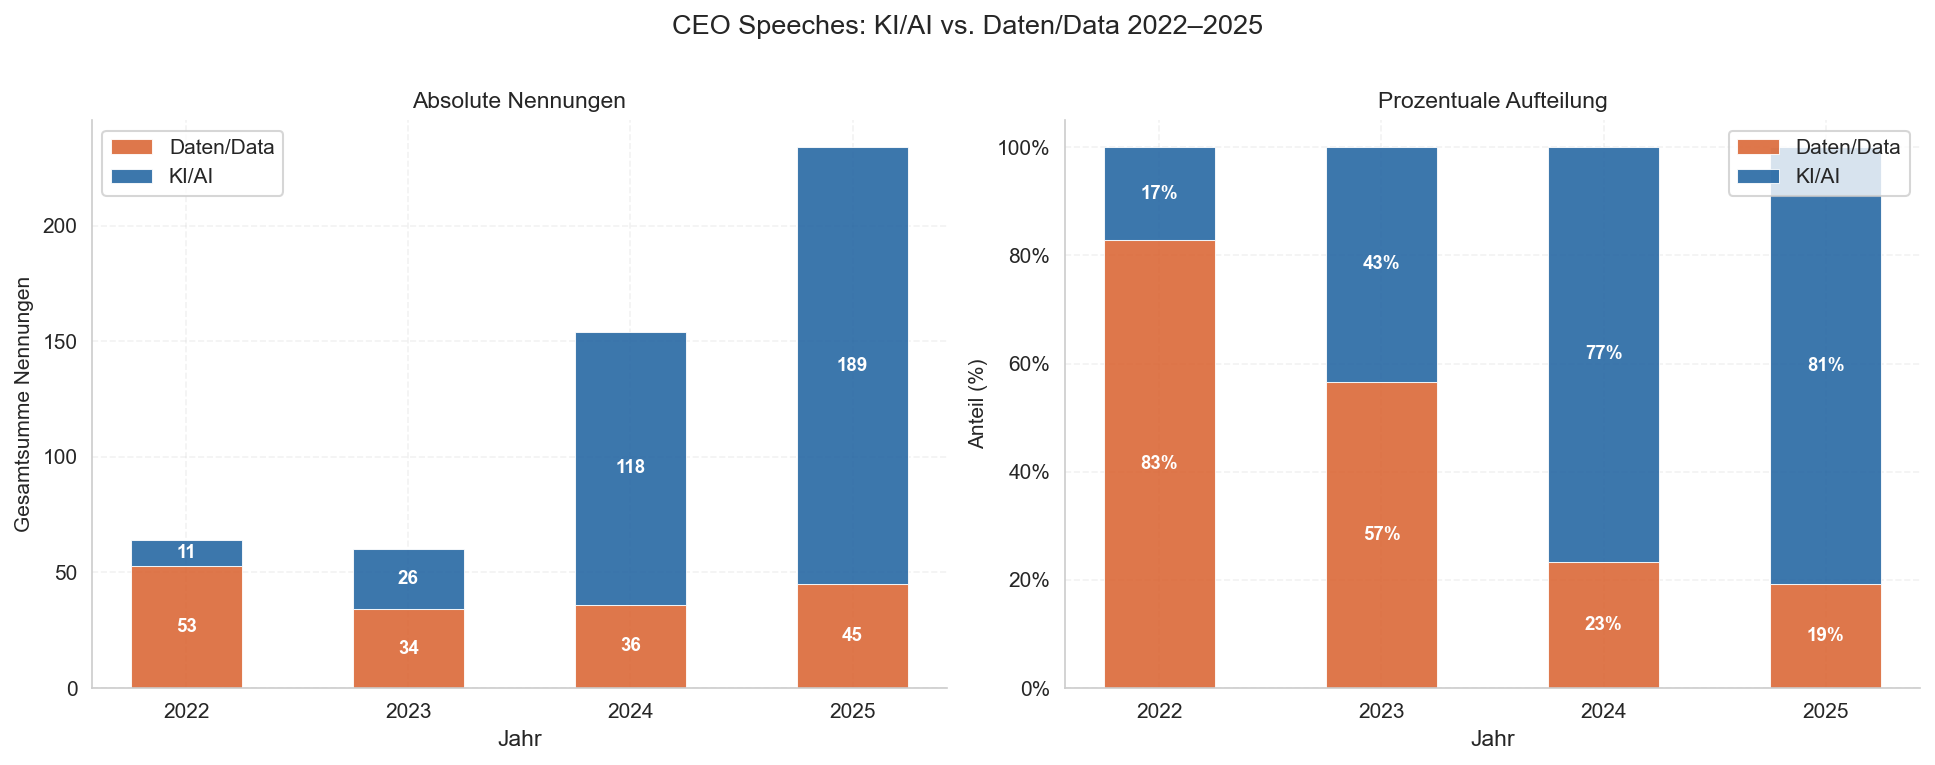

In [89]:
# ── PLOT 2 CEO ONLY: KI vs. Daten gestapelt ──────────────────────────────────

yearly_ceo_raw = freq[freq['role'] == 'ceo'].groupby(['year', 'group']).agg(
    raw_sum=('count_raw', 'sum'),
).reset_index()

pivot_ceo = yearly_ceo_raw.pivot_table(
    index='year', columns='group', values='raw_sum', fill_value=0
)
pivot_ceo['total'] = pivot_ceo.sum(axis=1)
for g in GROUPS:
    pivot_ceo[f'{g}_pct'] = pivot_ceo[g] / pivot_ceo['total'] * 100

fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CEO Speeches: KI/AI vs. Daten/Data 2022–2025', fontsize=13, y=1.01)

x = np.arange(len(YEARS))
bar_w = 0.5

for ax, value_col, ylabel, title, fmt in [
    (ax_abs, 'raw',  'Gesamtsumme Nennungen', 'Absolute Nennungen',     '{:.0f}'),
    (ax_pct, 'pct',  'Anteil (%)',             'Prozentuale Aufteilung', '{:.0f}%'),
]:
    bottom = np.zeros(len(YEARS))
    for group in ['Daten/Data', 'KI/AI']:
        col  = group if value_col == 'raw' else f'{group}_pct'
        vals = [pivot_ceo.loc[y, col] for y in YEARS]
        bars = ax.bar(x, vals, bar_w, bottom=bottom,
                      label=group, color=C[group], alpha=0.85,
                      edgecolor='white', linewidth=0.5)
        for rect, v, b in zip(bars, vals, bottom):
            if v > (3 if value_col == 'pct' else 1):
                ax.text(rect.get_x() + rect.get_width() / 2,
                        b + v / 2, fmt.format(v),
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
        bottom += np.array(vals)

    ax.set_xticks(x)
    ax.set_xticklabels(YEARS)
    ax.set_xlabel('Jahr', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    if value_col == 'pct':
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot2_ki_vs_daten_ceo_only.png', bbox_inches='tight')
plt.show()

════════════════════════════════════════════════════════════════════════════
PLOT 3 — Anteil Firmen mit mind. 1 Nennung, CEO vs. AR
════════════════════════════════════════════════════════════════════════════

In [67]:
# ════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Anteil Firmen mit mind. 1 Nennung, CEO vs. AR
# ════════════════════════════════════════════════════════════════════════════
print('\nErstelle Plot 3 ...')


Erstelle Plot 3 ...


  ✓ plot3_penetration_ceo_vs_ar.png


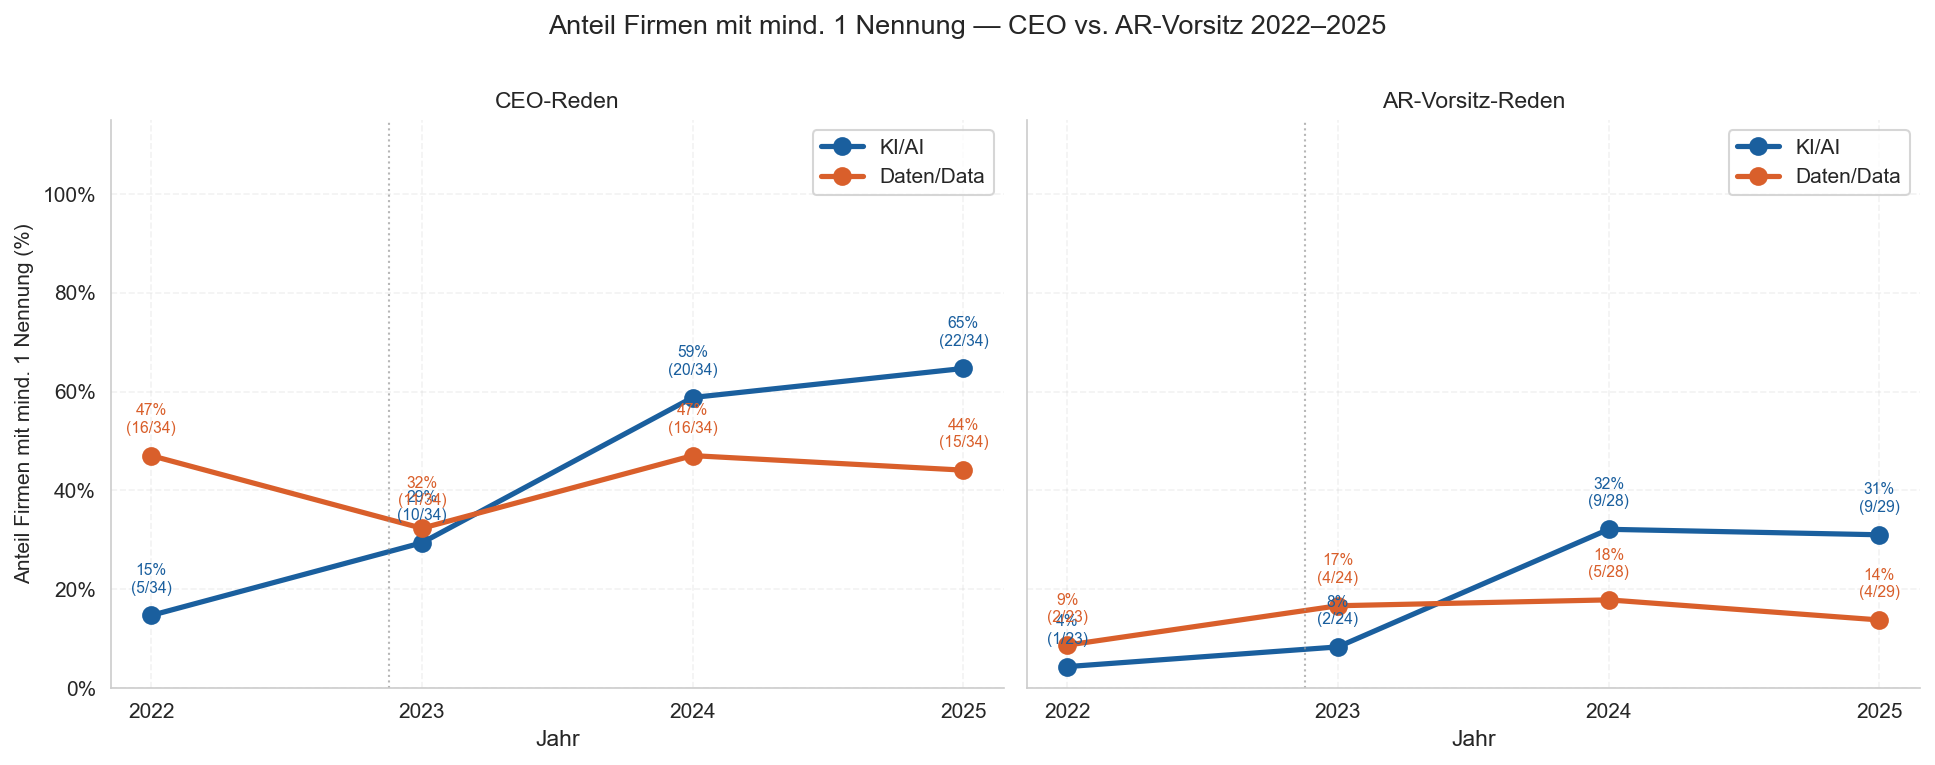

In [68]:
pen_rows = []
for year in YEARS:
    for group in GROUPS:
        for role in ['ceo', 'ar']:
            sub = freq[
                (freq['year'] == year) &
                (freq['group'] == group) &
                (freq['role'] == role)
            ]
            if sub.empty:
                continue
            total    = sub['company'].nunique()
            with_hit = sub[sub['count_raw'] > 0]['company'].nunique()
            pen_rows.append({
                'year':        year,
                'group':       group,
                'role':        role,
                'total_cos':   total,
                'cos_with_hit': with_hit,
                'pct':         with_hit / total * 100 if total > 0 else 0,
            })

pen = pd.DataFrame(pen_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(
    'Anteil Firmen mit mind. 1 Nennung — CEO vs. AR-Vorsitz 2022–2025',
    fontsize=13, y=1.01
)

role_labels = {'ceo': 'CEO-Reden', 'ar': 'AR-Vorsitz-Reden'}

for ax, role in zip(axes, ['ceo', 'ar']):
    for group in GROUPS:
        sub = pen[(pen['role'] == role) & (pen['group'] == group)].sort_values('year')
        ax.plot(sub['year'], sub['pct'], marker='o', linewidth=2.5,
                markersize=8, color=C[group], label=group)
        for _, row in sub.iterrows():
            ax.annotate(
                f"{row['pct']:.0f}%\n({int(row['cos_with_hit'])}/{int(row['total_cos'])})",
                (row['year'], row['pct']),
                xytext=(0, 11), textcoords='offset points',
                ha='center', fontsize=7.5, color=C[group]
            )
    ax.axvline(x=2022.88, color='#999', linestyle=':', linewidth=1, alpha=0.7)
    ax.set_xticks(YEARS)
    ax.set_xlabel('Jahr', fontsize=11)
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(role_labels[role], fontsize=11)
    ax.legend(fontsize=10)

axes[0].set_ylabel('Anteil Firmen mit mind. 1 Nennung (%)', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot3_penetration_ceo_vs_ar.png', bbox_inches='tight')
print('  ✓ plot3_penetration_ceo_vs_ar.png')
plt.show()

In [69]:
# ════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Top-3 & Null-Nennungen pro Jahr & Gruppe
# ════════════════════════════════════════════════════════════════════════════
print('\nErstelle Plot 4 ...')


Erstelle Plot 4 ...


  ✓ plot4_top3_zero_firmen.png


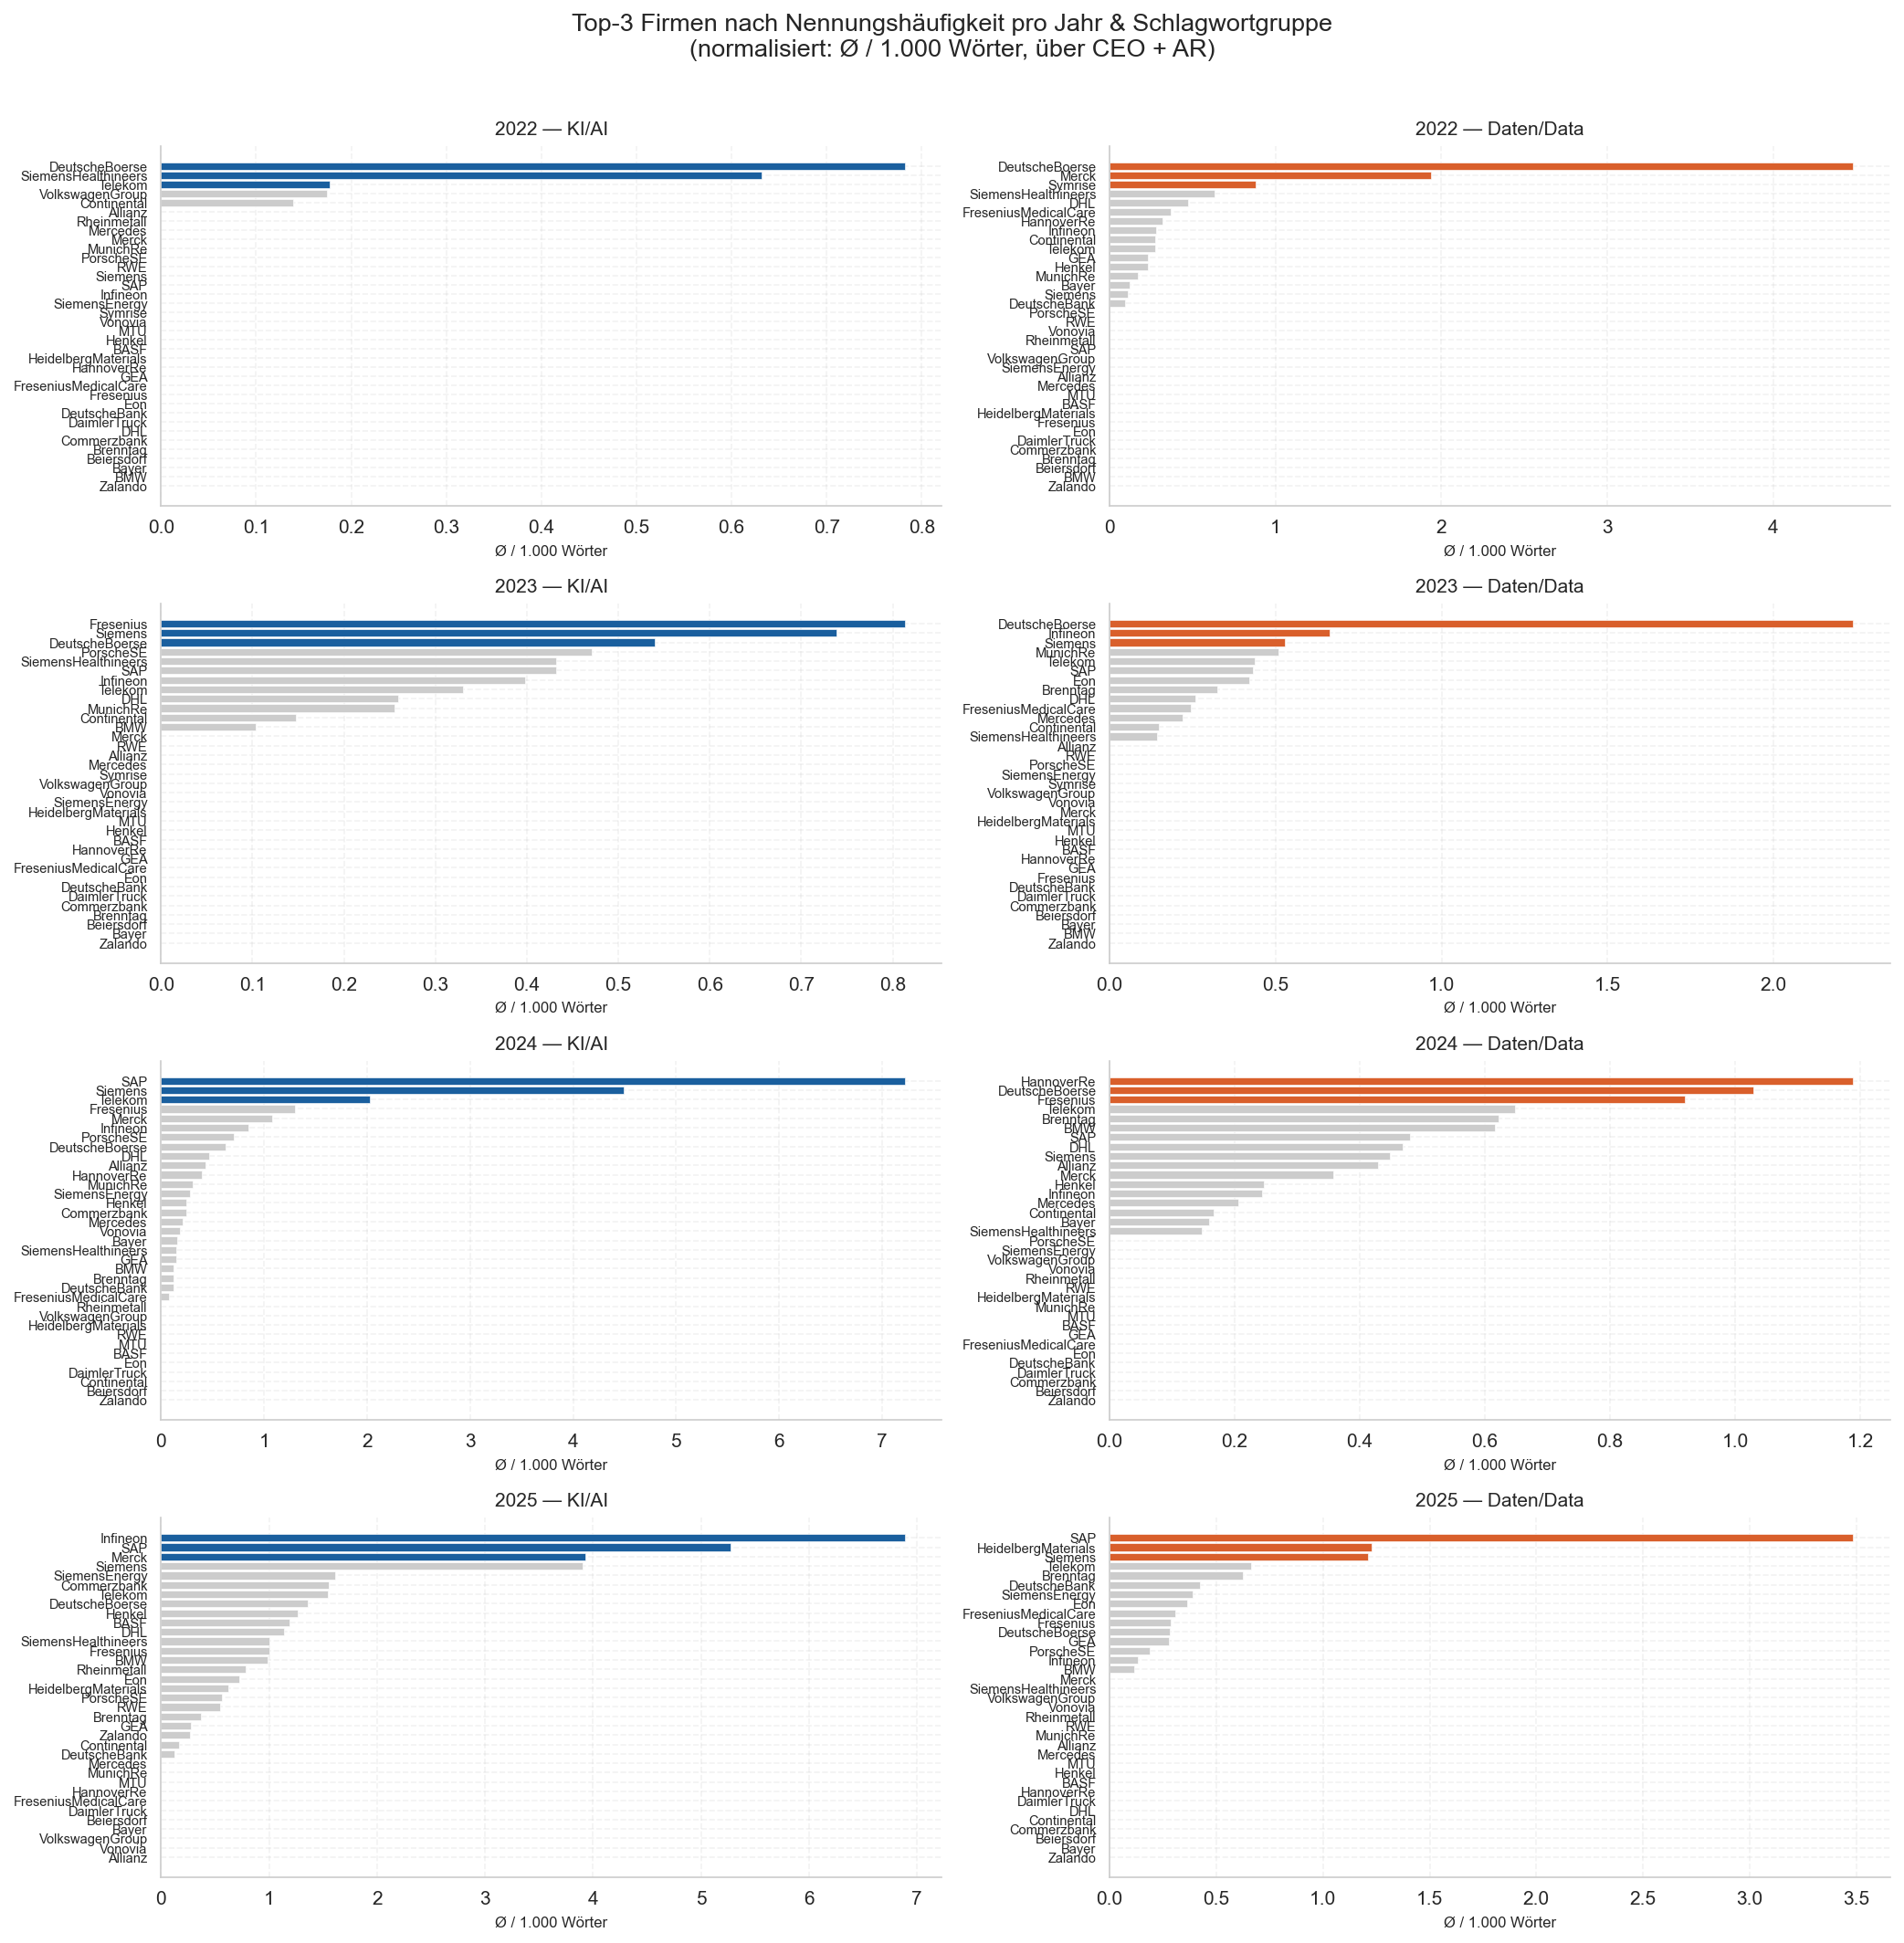

In [70]:
fig, axes = plt.subplots(
    len(YEARS), 2,
    figsize=(14, len(YEARS) * 3.5),
    sharey=False
)
fig.suptitle(
    'Top-3 Firmen nach Nennungshäufigkeit pro Jahr & Schlagwortgruppe\n'
    '(normalisiert: Ø / 1.000 Wörter, über CEO + AR)',
    fontsize=13, y=1.01
)

summary_rows = []

for row_i, year in enumerate(YEARS):
    for col_i, group in enumerate(GROUPS):
        ax  = axes[row_i][col_i]
        sub = agg[(agg['year'] == year) & (agg['group'] == group)]\
              .sort_values('count_norm', ascending=False).reset_index(drop=True)

        top3 = sub.head(3)
        zero = sub[sub['count_raw'] == 0]

        colors_bar = [C[group] if i < 3 else '#CCCCCC' for i in range(len(sub))]
        ax.barh(sub['company'], sub['count_norm'],
                color=colors_bar, edgecolor='white', linewidth=0.3)
        ax.set_title(f'{year} — {group}', fontsize=10)
        ax.set_xlabel('Ø / 1.000 Wörter', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.invert_yaxis()

        for _, r in top3.iterrows():
            summary_rows.append({
                'year': year, 'group': group, 'rank': 'Top',
                'company': r['company'],
                'count_norm': r['count_norm'],
                'count_raw':  r['count_raw'],
            })
        for _, r in zero.iterrows():
            summary_rows.append({
                'year': year, 'group': group, 'rank': 'Null',
                'company': r['company'],
                'count_norm': 0, 'count_raw': 0,
            })

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot4_top3_zero_firmen.png', bbox_inches='tight')
print('  ✓ plot4_top3_zero_firmen.png')
plt.show()

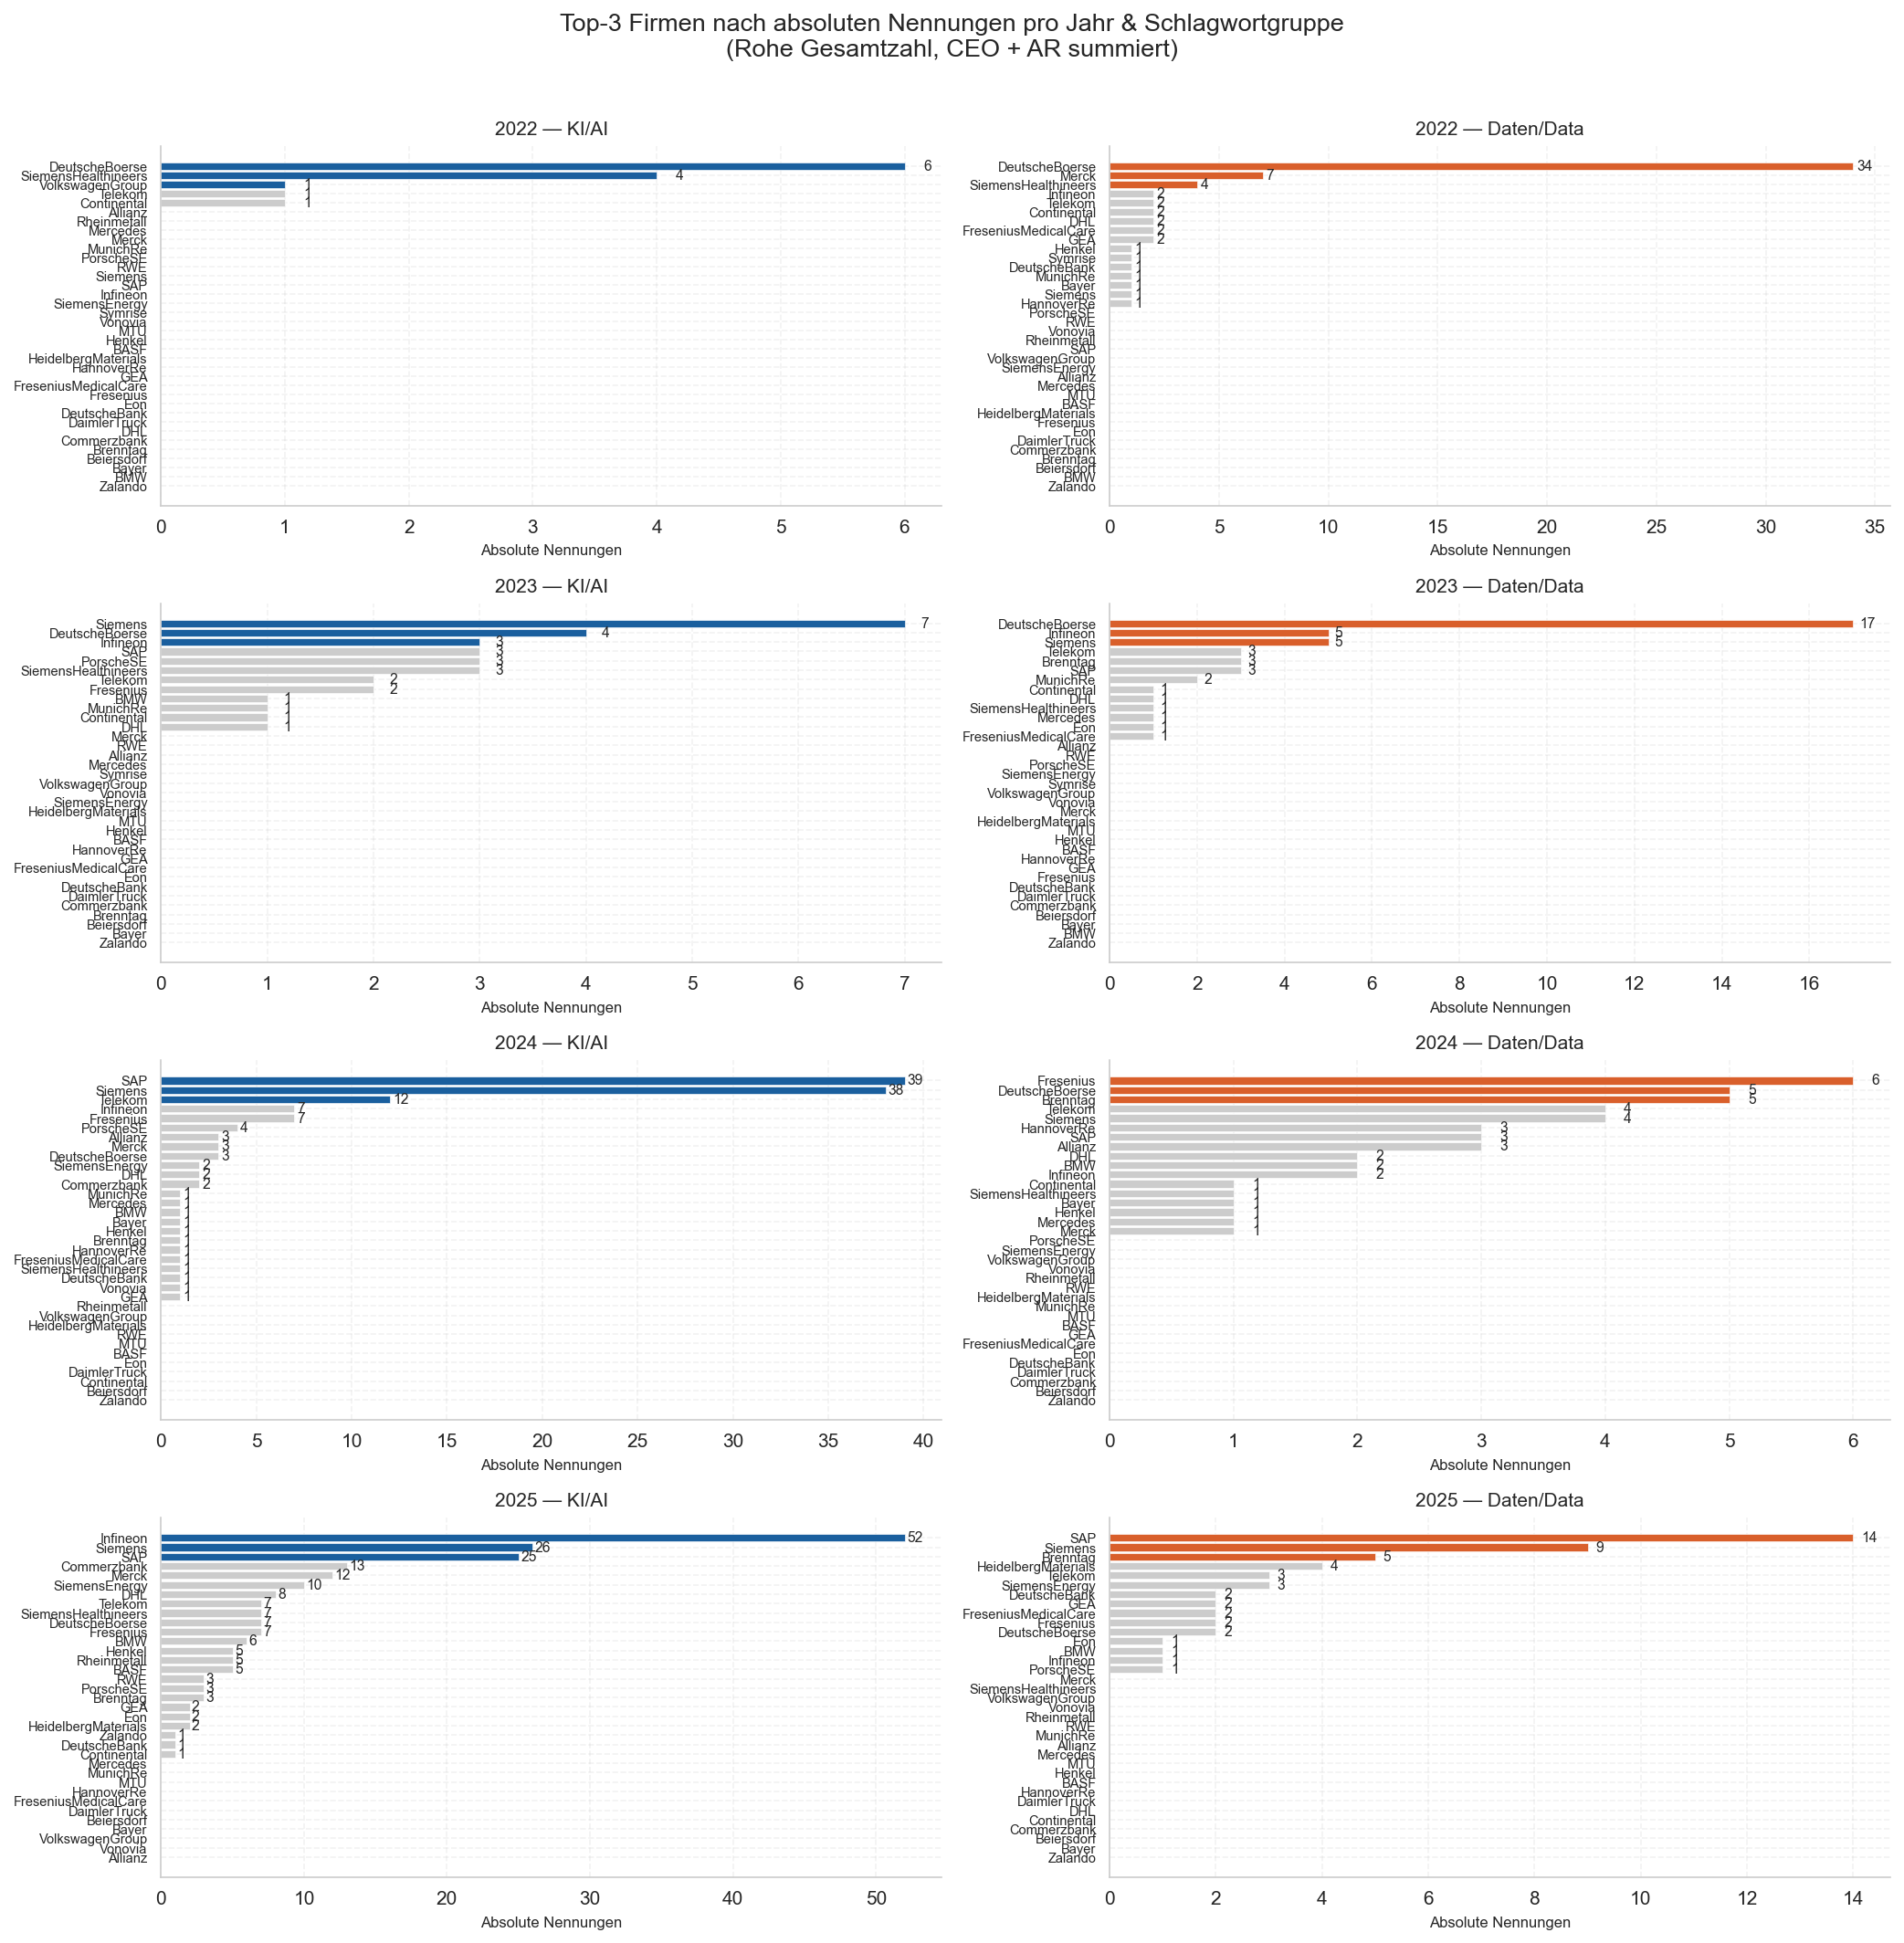

In [75]:
# ── TOP-3 & NULL-NENNUNGEN: ABSOLUT (nicht normiert) ─────────────────────────
fig, axes = plt.subplots(len(YEARS), 2,
                          figsize=(14, len(YEARS) * 3.5), sharey=False)
fig.suptitle('Top-3 Firmen nach absoluten Nennungen pro Jahr & Schlagwortgruppe\n'
             '(Rohe Gesamtzahl, CEO + AR summiert)',
             fontsize=13, y=1.01)

for row_i, year in enumerate(YEARS):
    for col_i, group in enumerate(GROUPS):
        ax  = axes[row_i][col_i]
        sub = agg[(agg['year'] == year) & (agg['group'] == group)]\
              .sort_values('count_raw', ascending=False).reset_index(drop=True)

        colors_bar = [C[group] if i < 3 else '#CCCCCC' for i in range(len(sub))]
        bars = ax.barh(sub['company'], sub['count_raw'],
                       color=colors_bar, edgecolor='white', linewidth=0.3)

        for bar, v in zip(bars, sub['count_raw']):
            if v > 0:
                ax.text(v + 0.15, bar.get_y() + bar.get_height() / 2,
                        str(int(v)), va='center', fontsize=7.5)

        ax.set_title(f'{year} — {group}', fontsize=10)
        ax.set_xlabel('Absolute Nennungen', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_top3_absolut.png', bbox_inches='tight')
plt.show()

In [71]:
# Textausgabe & Export
summary = pd.DataFrame(summary_rows)
summary.to_csv(REP_DIR / 'top3_zero_summary.csv', index=False, encoding='utf-8-sig')

In [72]:
for year in YEARS:
    print(f'\n{"═"*60}')
    print(f'  {year}')
    print(f'{"═"*60}')
    for group in GROUPS:
        s    = summary[(summary['year'] == year) & (summary['group'] == group)]
        top  = s[s['rank'] == 'Top']
        zero = s[s['rank'] == 'Null']
        print(f'\n  {group}')
        print('  Top-3:')
        for _, r in top.iterrows():
            print(f'    {r["company"]:25}  {r["count_norm"]:.2f}/1000  '
                  f'({int(r["count_raw"])} Nennungen)')
        zero_list = ', '.join(zero['company'].tolist()) if not zero.empty else '–'
        print(f'  Keine Nennung: {zero_list}')


════════════════════════════════════════════════════════════
  2022
════════════════════════════════════════════════════════════

  KI/AI
  Top-3:
    DeutscheBoerse             0.78/1000  (6 Nennungen)
    SiemensHealthineers        0.63/1000  (4 Nennungen)
    Telekom                    0.18/1000  (1 Nennungen)
  Keine Nennung: Allianz, Rheinmetall, Mercedes, Merck, MunichRe, PorscheSE, RWE, Siemens, SAP, Infineon, SiemensEnergy, Symrise, Vonovia, MTU, Henkel, BASF, HeidelbergMaterials, HannoverRe, GEA, FreseniusMedicalCare, Fresenius, Eon, DeutscheBank, DaimlerTruck, DHL, Commerzbank, Brenntag, Beiersdorf, Bayer, BMW, Zalando

  Daten/Data
  Top-3:
    DeutscheBoerse             4.48/1000  (34 Nennungen)
    Merck                      1.94/1000  (7 Nennungen)
    Symrise                    0.88/1000  (1 Nennungen)
  Keine Nennung: PorscheSE, RWE, Vonovia, Rheinmetall, SAP, VolkswagenGroup, SiemensEnergy, Allianz, Mercedes, MTU, BASF, HeidelbergMaterials, Fresenius, Eon, DaimlerTruc

## Plot 5 - Verteilung Nennungshäufigkeit

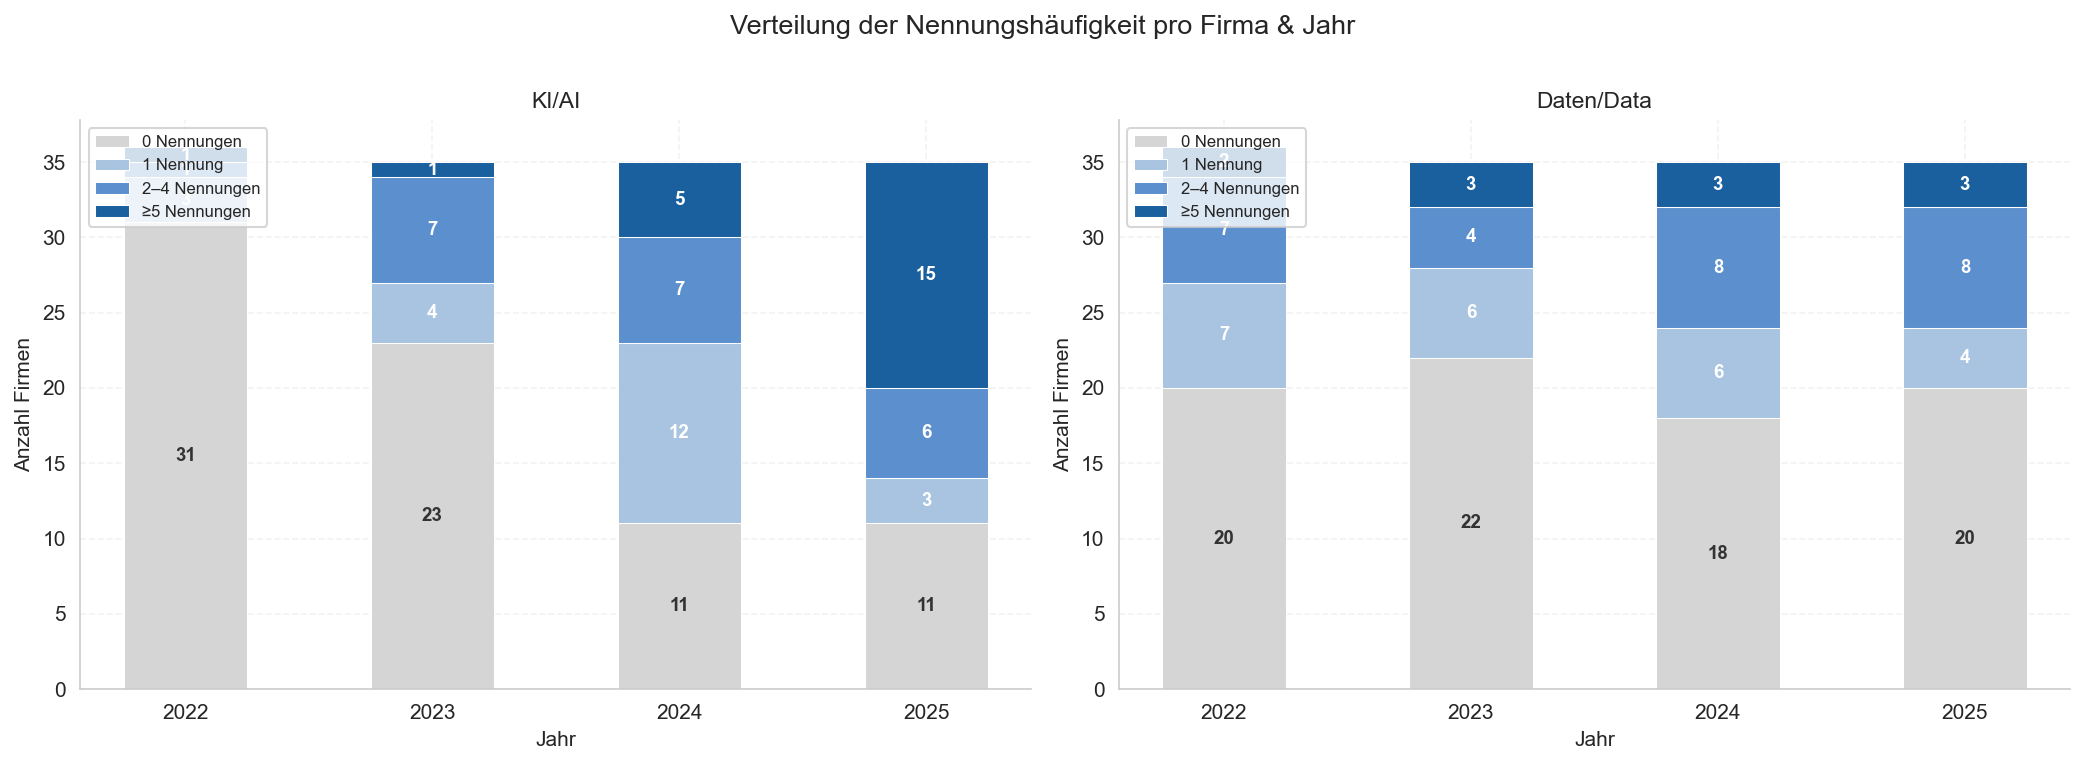

In [74]:
# ── CLUSTER-ANALYSE: Verteilung der Nennungshäufigkeit ───────────────────────
cluster_rows = []
for group in GROUPS:
    sub = agg[agg['group'] == group].copy()
    sub['cluster'] = pd.cut(
        sub['count_raw'],
        bins=[-1, 0, 1, 4, float('inf')],
        labels=['0 Nennungen', '1 Nennung', '2–4 Nennungen', '≥5 Nennungen']
    )
    counts = sub.groupby(['year', 'cluster'], observed=True).size().reset_index(name='n_companies')
    counts['group'] = group
    cluster_rows.append(counts)

cluster_df = pd.concat(cluster_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Verteilung der Nennungshäufigkeit pro Firma & Jahr', fontsize=13, y=1.01)

cluster_colors = {
    '0 Nennungen':   '#D5D5D5',
    '1 Nennung':     '#A8C4E0',
    '2–4 Nennungen': '#5B8FCE',
    '≥5 Nennungen':  '#1A5F9E',
}

for ax, group in zip(axes, GROUPS):
    sub = cluster_df[cluster_df['group'] == group]
    pivot = sub.pivot_table(index='year', columns='cluster', values='n_companies', fill_value=0)
    pivot = pivot.reindex(columns=['0 Nennungen', '1 Nennung', '2–4 Nennungen', '≥5 Nennungen'])

    bottom = np.zeros(len(pivot))
    for col in pivot.columns:
        vals = pivot[col].values
        bars = ax.bar(pivot.index, vals, bottom=bottom,
                      label=col, color=cluster_colors[col],
                      edgecolor='white', linewidth=0.5, width=0.5)
        for rect, v, b in zip(bars, vals, bottom):
            if v > 0:
                ax.text(rect.get_x() + rect.get_width() / 2,
                        b + v / 2, str(int(v)),
                        ha='center', va='center', fontsize=9,
                        color='#333' if col == '0 Nennungen' else 'white',
                        fontweight='bold')
        bottom += vals

    ax.set_title(group, fontsize=11)
    ax.set_xlabel('Jahr', fontsize=10)
    ax.set_ylabel('Anzahl Firmen', fontsize=10)
    ax.set_xticks(YEARS)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_cluster_verteilung.png', bbox_inches='tight')
plt.show()

## Plot 6 - Summe Nennungen pro Firma

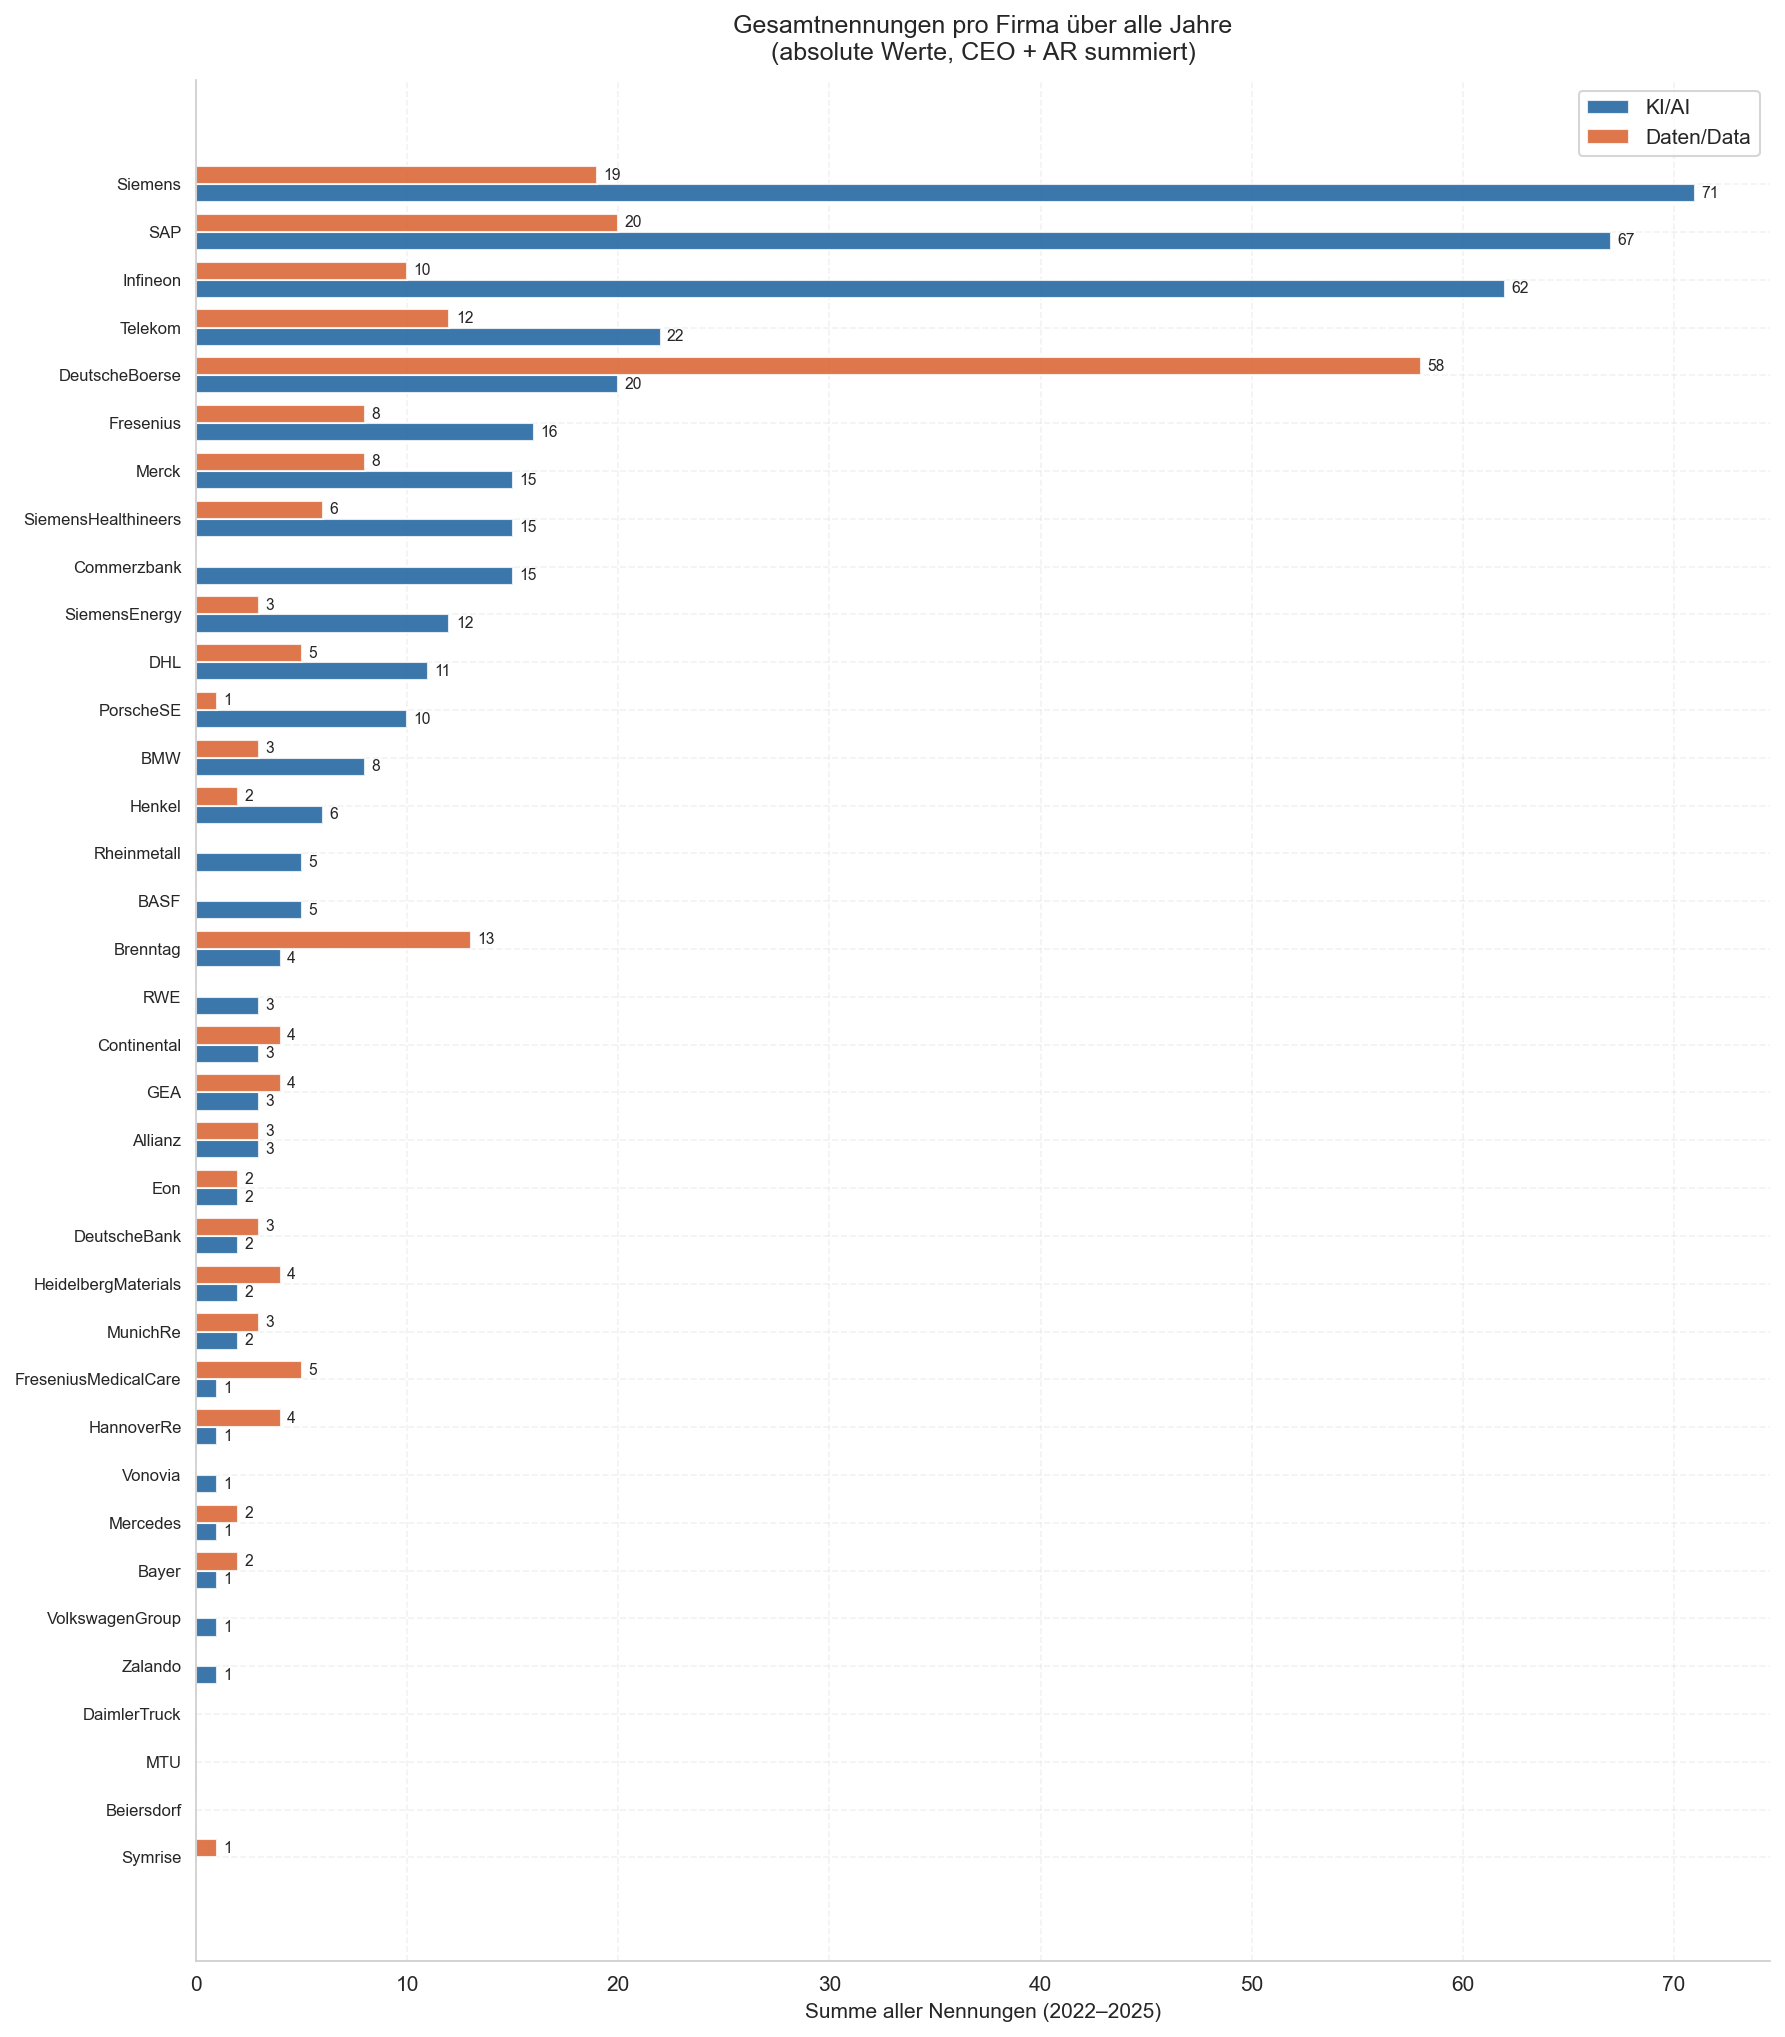


Gesamtnennungen pro Firma (sortiert nach KI/AI):
group                 Daten/Data  KI/AI
company                                
Siemens                     19.0   71.0
SAP                         20.0   67.0
Infineon                    10.0   62.0
Telekom                     12.0   22.0
DeutscheBoerse              58.0   20.0
Fresenius                    8.0   16.0
Commerzbank                  0.0   15.0
SiemensHealthineers          6.0   15.0
Merck                        8.0   15.0
SiemensEnergy                3.0   12.0
DHL                          5.0   11.0
PorscheSE                    1.0   10.0
BMW                          3.0    8.0
Henkel                       2.0    6.0
Rheinmetall                  0.0    5.0
BASF                         0.0    5.0
Brenntag                    13.0    4.0
RWE                          0.0    3.0
GEA                          4.0    3.0
Allianz                      3.0    3.0
Continental                  4.0    3.0
Eon                          2

In [76]:
# ── GESAMT-NENNUNGEN PRO FIRMA (2022–2025 summiert) ──────────────────────────
total_per_firm = agg.groupby(['company', 'group'])['count_raw'].sum().reset_index()
pivot_firms = total_per_firm.pivot_table(
    index='company', columns='group', values='count_raw', fill_value=0
).sort_values('KI/AI', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot_firms) * 0.38)))

x     = np.arange(len(pivot_firms))
width = 0.38

bars1 = ax.barh(x - width/2, pivot_firms['KI/AI'],    width, label='KI/AI',
                color=C['KI/AI'],      alpha=0.85, edgecolor='white')
bars2 = ax.barh(x + width/2, pivot_firms['Daten/Data'], width, label='Daten/Data',
                color=C['Daten/Data'], alpha=0.85, edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        w = bar.get_width()
        if w > 0:
            ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                    str(int(w)), va='center', fontsize=7.5)

ax.set_yticks(x)
ax.set_yticklabels(pivot_firms.index, fontsize=8)
ax.set_xlabel('Summe aller Nennungen (2022–2025)', fontsize=10)
ax.set_title('Gesamtnennungen pro Firma über alle Jahre\n(absolute Werte, CEO + AR summiert)',
             fontsize=12, pad=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_gesamtnennungen_pro_firma.png', bbox_inches='tight')
plt.show()

# Tabelle ausgeben
print('\nGesamtnennungen pro Firma (sortiert nach KI/AI):')
print(pivot_firms.sort_values('KI/AI', ascending=False).to_string())

## Plot 7

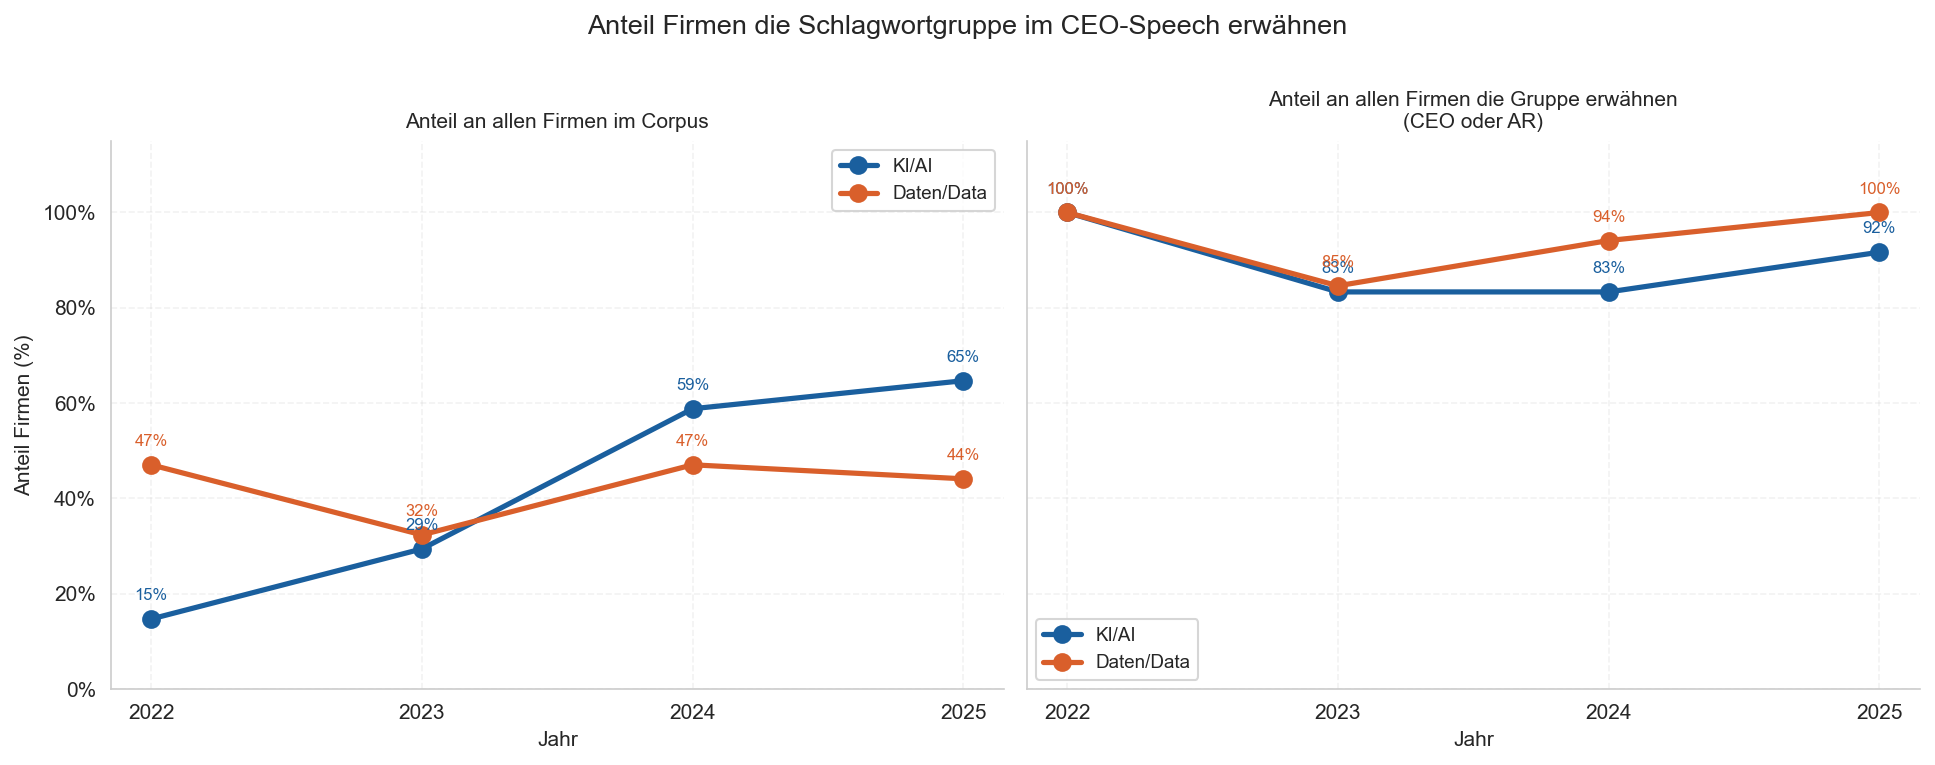

In [77]:
# ── CEO-ANTEIL: KI/Data in CEO-Speeches ──────────────────────────────────────
ceo_rows = []
for year in YEARS:
    for group in GROUPS:
        all_ceo  = freq[(freq['year']==year) & (freq['role']=='ceo') & (freq['group']==group)]
        total    = all_ceo['company'].nunique()
        with_hit = all_ceo[all_ceo['count_raw'] > 0]['company'].nunique()

        # Anteil an allen KI-Erwähnern (CEO + AR)
        all_any  = freq[(freq['year']==year) & (freq['group']==group)]
        ki_firms = all_any[all_any['count_raw'] > 0]['company'].nunique()

        ceo_rows.append({
            'year':              year,
            'group':             group,
            'total_ceo_firms':   total,
            'ceo_with_hit':      with_hit,
            'pct_of_all':        with_hit / total * 100 if total > 0 else 0,
            'pct_of_ki_firms':   with_hit / ki_firms * 100 if ki_firms > 0 else 0,
        })

ceo_df = pd.DataFrame(ceo_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Anteil Firmen die Schlagwortgruppe im CEO-Speech erwähnen', fontsize=13, y=1.01)

titles = {
    'pct_of_all':      'Anteil an allen Firmen im Corpus',
    'pct_of_ki_firms': 'Anteil an allen Firmen die Gruppe erwähnen\n(CEO oder AR)',
}

for ax, (col, title) in zip(axes, titles.items()):
    for group in GROUPS:
        sub = ceo_df[ceo_df['group'] == group].sort_values('year')
        ax.plot(sub['year'], sub[col], marker='o', linewidth=2.5,
                markersize=8, color=C[group], label=group)
        for _, row in sub.iterrows():
            ax.annotate(f"{row[col]:.0f}%",
                        (row['year'], row[col]),
                        xytext=(0, 9), textcoords='offset points',
                        ha='center', fontsize=8, color=C[group])
    ax.set_title(title, fontsize=10)
    ax.set_xticks(YEARS)
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Jahr', fontsize=10)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Anteil Firmen (%)', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_ceo_anteil.png', bbox_inches='tight')
plt.show()

## Plot 7.2 CEO: Von KI-Erwähnern → wie viele erwähnen auch Daten?

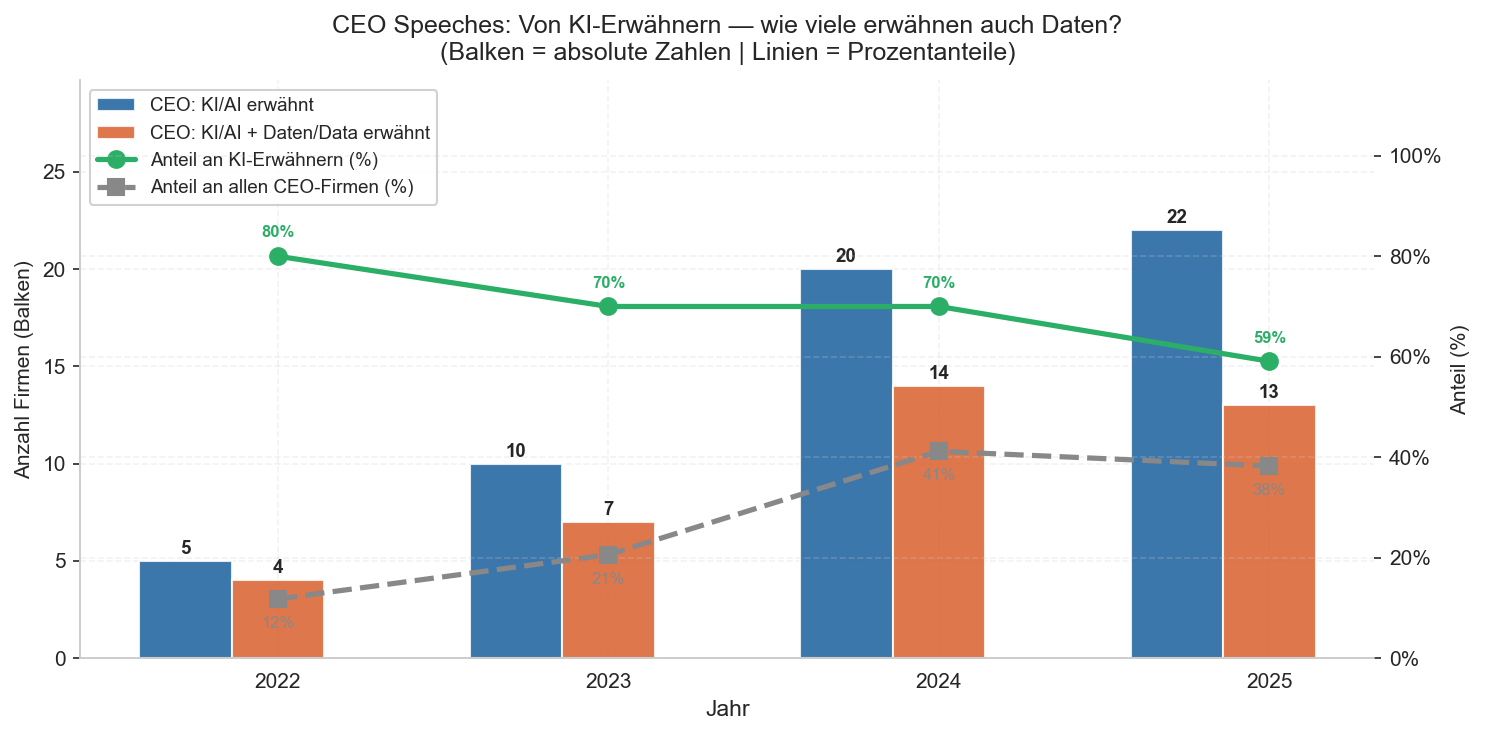


Rohdaten:
 year  n_total_ceo  n_ki  n_both  pct_of_ki  pct_of_all
 2022           34     5       4       80.0        11.8
 2023           34    10       7       70.0        20.6
 2024           34    20      14       70.0        41.2
 2025           34    22      13       59.1        38.2


In [85]:
# ── CEO: Von KI-Erwähnern → wie viele erwähnen auch Daten? ───────────────────

rows = []
for year in YEARS:
    ceo = freq[(freq['year'] == year) & (freq['role'] == 'ceo')]

    # Firmen mit mind. 1 KI-Nennung im CEO Speech
    ki_firms   = set(ceo[(ceo['group'] == 'KI/AI')    & (ceo['count_raw'] > 0)]['company'])
    # Firmen mit mind. 1 Daten-Nennung im CEO Speech
    data_firms = set(ceo[(ceo['group'] == 'Daten/Data') & (ceo['count_raw'] > 0)]['company'])
    # Firmen die BEIDE erwähnen
    both_firms = ki_firms & data_firms

    total_ceo = ceo['company'].nunique()

    rows.append({
        'year':          year,
        'n_total_ceo':   total_ceo,
        'n_ki':          len(ki_firms),
        'n_both':        len(both_firms),
        'pct_of_ki':     len(both_firms) / len(ki_firms)   * 100 if ki_firms   else 0,
        'pct_of_all':    len(both_firms) / total_ceo * 100 if total_ceo else 0,
    })

df = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x     = np.arange(len(YEARS))
width = 0.28

# ── Balken ──
b1 = ax1.bar(x - width, df['n_ki'],   width, label='CEO: KI/AI erwähnt',
             color=C['KI/AI'],      alpha=0.85, edgecolor='white')
b2 = ax1.bar(x,         df['n_both'], width, label='CEO: KI/AI + Daten/Data erwähnt',
             color=C['Daten/Data'], alpha=0.85, edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.15,
                     str(int(h)), ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Linien ──
ax2.plot(x, df['pct_of_ki'],  marker='o', linewidth=2.5, markersize=8,
         color='#2BAE66', label='Anteil an KI-Erwähnern (%)')
ax2.plot(x, df['pct_of_all'], marker='s', linewidth=2.5, markersize=8,
         color='#888', linestyle='--', label='Anteil an allen CEO-Firmen (%)')

for _, row in df.iterrows():
    i = YEARS.index(row['year'])
    ax2.annotate(f"{row['pct_of_ki']:.0f}%",
                 (i, row['pct_of_ki']),
                 xytext=(0, 9), textcoords='offset points',
                 ha='center', fontsize=8, color='#2BAE66', fontweight='bold')
    ax2.annotate(f"{row['pct_of_all']:.0f}%",
                 (i, row['pct_of_all']),
                 xytext=(0, -14), textcoords='offset points',
                 ha='center', fontsize=8, color='#888')

ax1.set_xticks(x)
ax1.set_xticklabels(YEARS)
ax1.set_xlabel('Jahr', fontsize=11)
ax1.set_ylabel('Anzahl Firmen (Balken)', fontsize=10)
ax2.set_ylabel('Anteil (%)', fontsize=10)
ax1.set_ylim(0, max(df['n_ki'].max(), 1) * 1.35)
ax2.set_ylim(0, 115)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9,
           loc='upper left', framealpha=0.9)

ax1.set_title('CEO Speeches: Von KI-Erwähnern — wie viele erwähnen auch Daten?\n'
              '(Balken = absolute Zahlen | Linien = Prozentanteile)',
              fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_ki_dann_daten_ceo.png', bbox_inches='tight')
plt.show()

print('\nRohdaten:')
print(df[['year','n_total_ceo','n_ki','n_both','pct_of_ki','pct_of_all']]
      .round(1).to_string(index=False))

## Plot 8 - Co-Occurence

In [78]:
# ── CO-OCCURRENCE: DATEN-KONTEXT ──────────────────────────────────────────────
# Wörter die innerhalb von ±10 Wörtern um "Daten" auftreten

import re
from collections import Counter

# ── A: Häufigste Nachbarwörter (Word Cloud) ──
STOPWORDS_DE = {
    'der','die','das','und','in','zu','den','des','von','mit','auf','für',
    'ist','im','an','als','auch','sich','es','ein','eine','einer','einem',
    'wir','sie','nicht','dass','aus','bei','durch','nach','bis','über',
    'sind','haben','wird','werden','wurde','wurden','hat','hatte','kann',
    'um','so','wie','aber','oder','wenn','uns','ihm','ihr','ihn','ihre',
    'dem','war','einer','einem','eines','unserem','unsere','unserer',
    'haben','dabei','bereits','sowie','noch','mehr','kann','können',
}

WINDOW = 10
neighbor_counts = Counter()

for _, doc in corpus.iterrows():
    words = doc['text'].lower().split()
    for i, w in enumerate(words):
        clean_w = re.sub(r'[^a-zäöüß]', '', w)
        if clean_w in ['daten', 'data']:
            start = max(0, i - WINDOW)
            end   = min(len(words), i + WINDOW + 1)
            for neighbor in words[start:end]:
                n_clean = re.sub(r'[^a-zäöüß\-]', '', neighbor)
                if n_clean and n_clean not in STOPWORDS_DE and len(n_clean) > 3:
                    neighbor_counts[n_clean] += 1

# Word Cloud
try:
    from wordcloud import WordCloud
    wc = WordCloud(
        width=900, height=450, background_color='white',
        colormap='Blues', max_words=80,
        font_path=None,
    ).generate_from_frequencies(dict(neighbor_counts.most_common(150)))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Häufigste Nachbarwörter von "Daten/Data" (±10 Wörter)',
                 fontsize=13, pad=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'plot_daten_wordcloud.png', bbox_inches='tight')
    plt.show()
except ImportError:
    print('WordCloud nicht installiert. Führe aus: pip install wordcloud')
    print('\nTop-30 Nachbarwörter:')
    for word, count in neighbor_counts.most_common(30):
        print(f'  {word:25} {count:>4}')

# ── B: Gezielte Satzsuche: Daten + Strategie-Begriff im selben Satz ──
DATA_STRATEGY_TERMS = [
    'strategie', 'strategy', 'verfügbarkeit', 'availability',
    'silo', 'eigentum', 'ownership', 'proprietär', 'proprietary',
    'qualität', 'quality', 'governance', 'architektur', 'architecture',
    'plattform', 'platform', 'infrastruktur', 'infrastructure',
]

hit_rows = []
for _, doc in corpus.iterrows():
    sentences = re.split(r'(?<=[.!?])\s+', doc['text'])
    for sent in sentences:
        sent_lower = sent.lower()
        has_data = bool(re.search(r'\b(daten|data)\b', sent_lower))
        if not has_data:
            continue
        for strat_term in DATA_STRATEGY_TERMS:
            if strat_term in sent_lower:
                hit_rows.append({
                    'company':   doc['company'],
                    'year':      doc['year'],
                    'role':      doc['role'],
                    'strat_term': strat_term,
                    'sentence':  sent.strip()[:300],
                })

hits_df = pd.DataFrame(hit_rows)
hits_df.to_csv(REP_DIR / 'daten_strategie_saetze.csv', index=False, encoding='utf-8-sig')
print(f'\nDaten + Strategie-Begriff im selben Satz: {len(hits_df)} Treffer')
print(f'Häufigste Kombinations-Terme:')
print(hits_df['strat_term'].value_counts().head(10).to_string())
print(f'\n✓ Alle Sätze exportiert: {REP_DIR}/daten_strategie_saetze.csv')

WordCloud nicht installiert. Führe aus: pip install wordcloud

Top-30 Nachbarwörter:
  daten                      180
  intelligenz                 27
  data                        24
  unser                       18
  kunden                      18
  daten-                      18
  nutzen                      16
  diese                       15
  digitalisierung             15
  künstliche                  15
  cloud                       14
  unseren                     12
  einen                       11
  machen                      11
  neue                        11
  software                    11
  analytik                    10
  unternehmen                  9
  produzieren                  9
  besser                       8
  drei                         8
  märkte                       8
  stehen                       8
  zentrum                      8
  unseres                      8
  rohstoff                     8
  business                     8
  jahr                  

## Plot 9 - Consistency

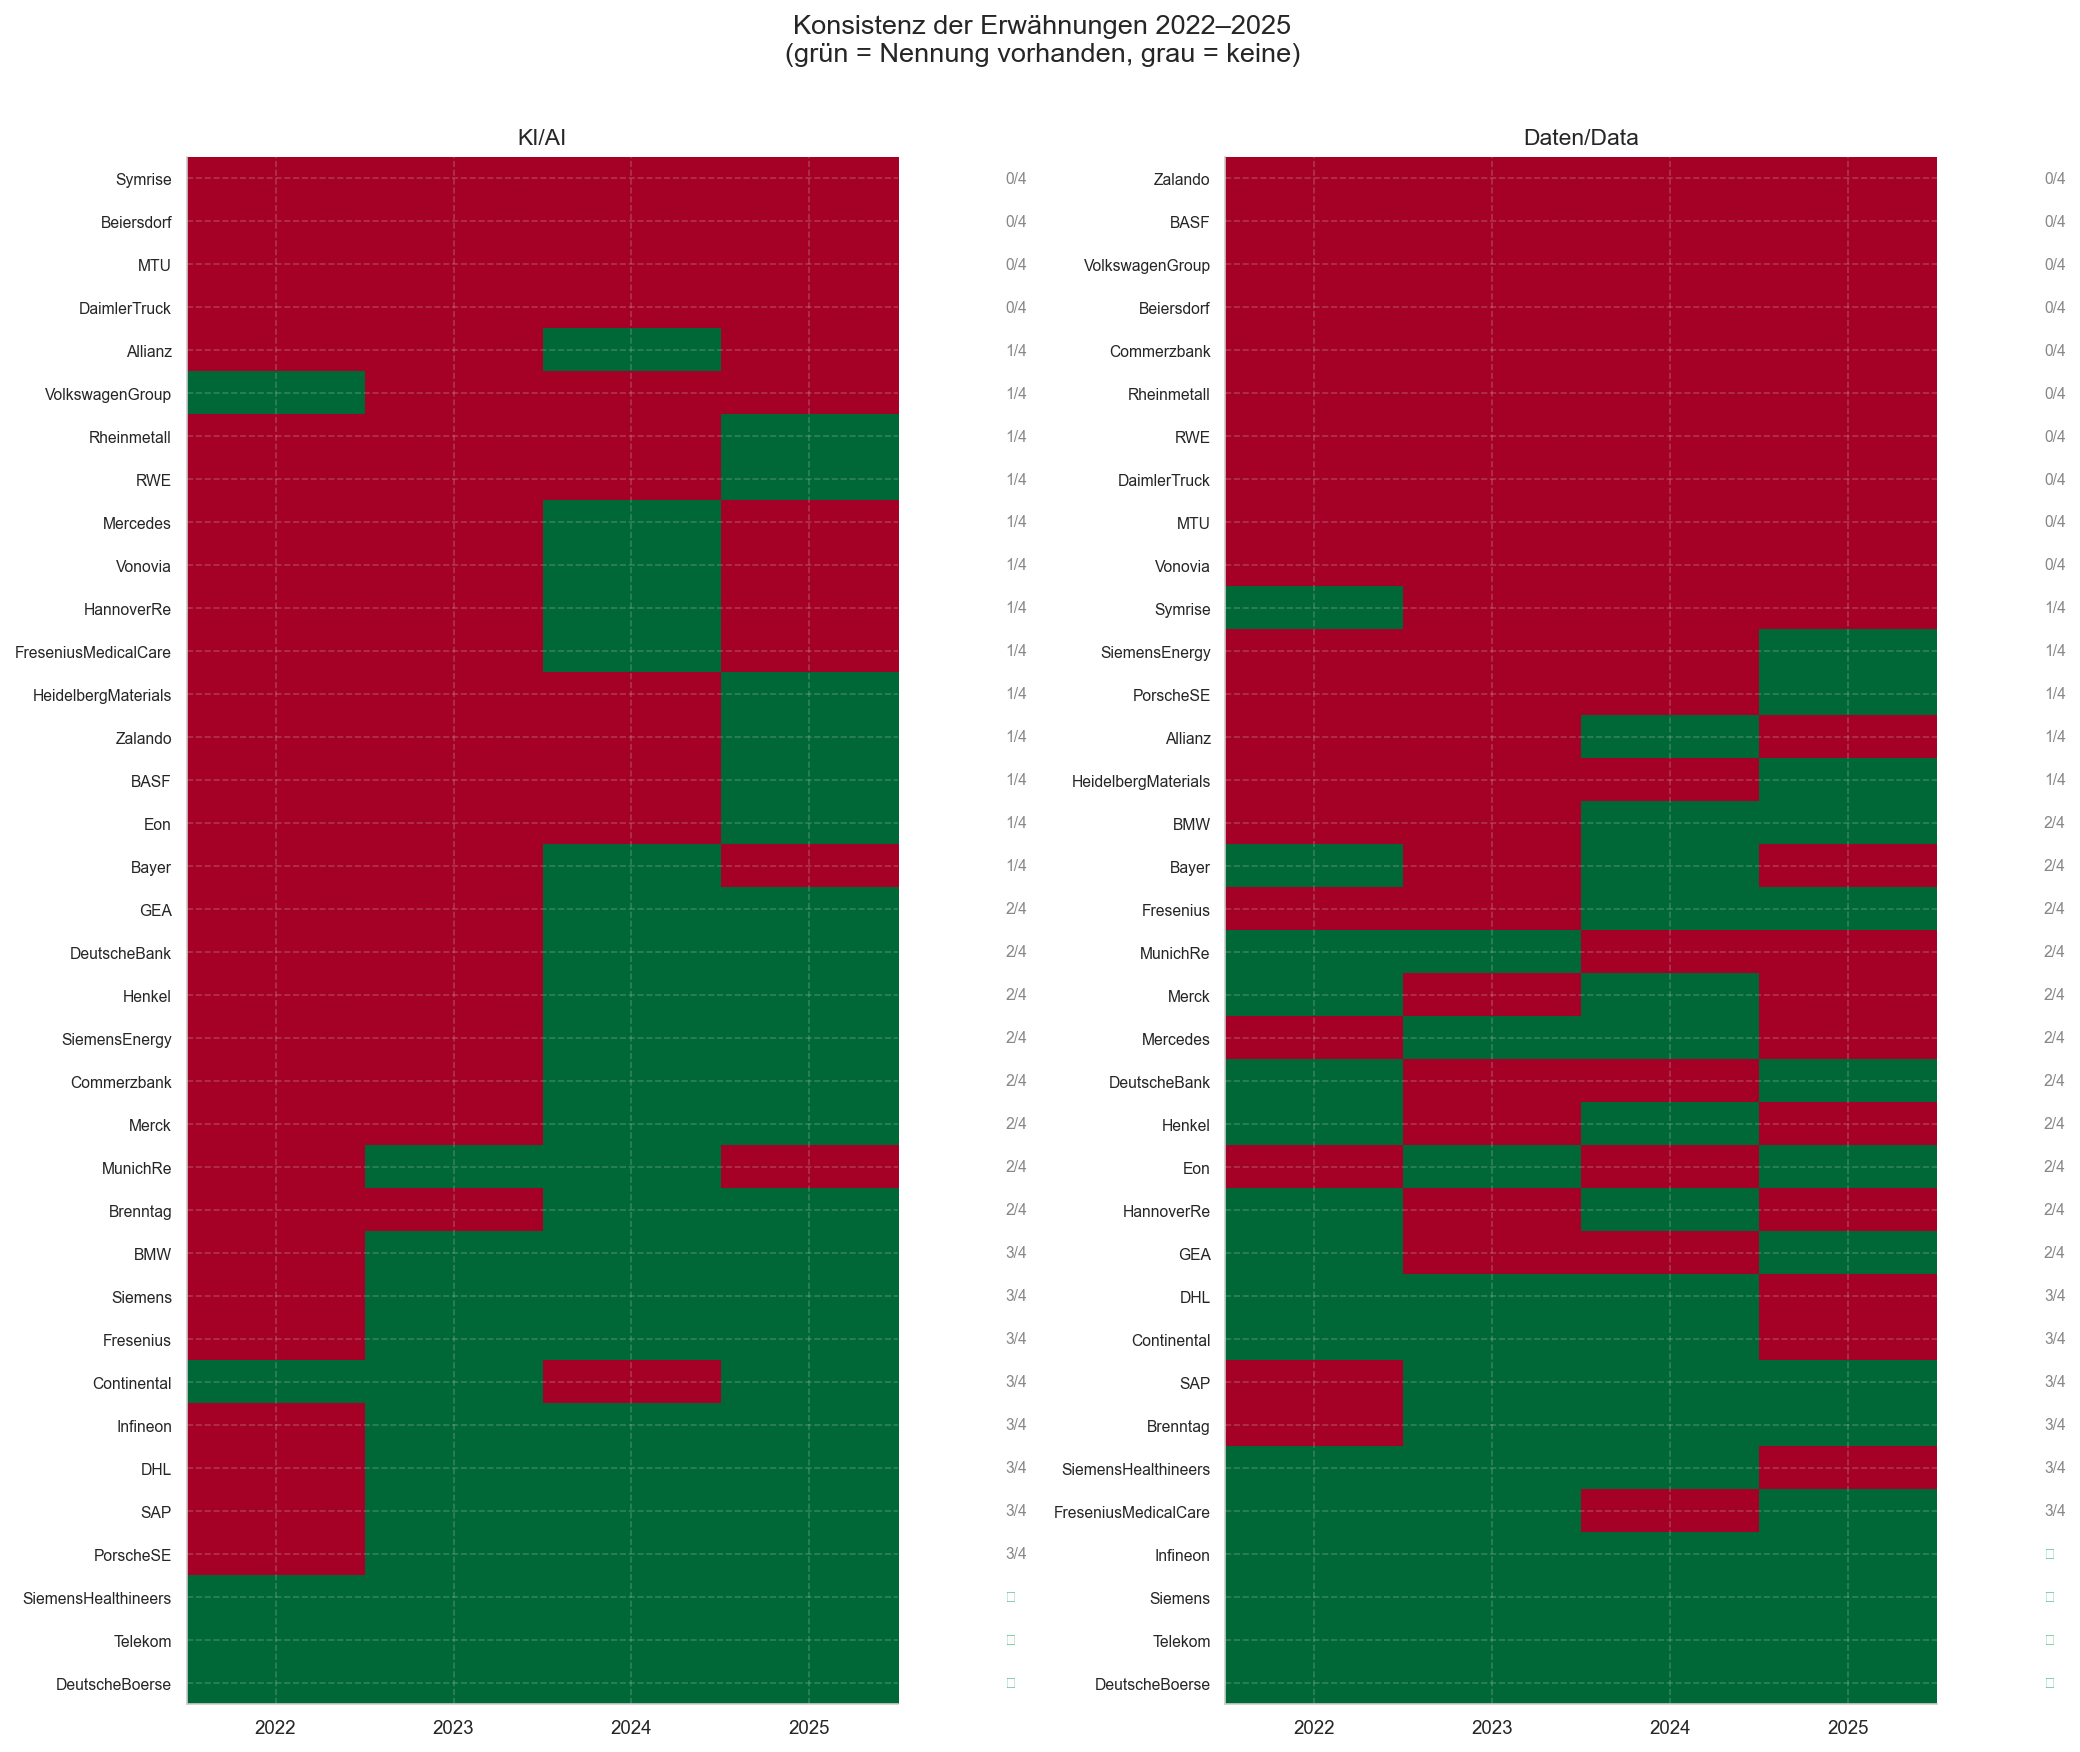


KI/AI — Firmen mit Nennung in allen 4 Jahren (3):
  ★ DeutscheBoerse
  ★ SiemensHealthineers
  ★ Telekom

Daten/Data — Firmen mit Nennung in allen 4 Jahren (4):
  ★ DeutscheBoerse
  ★ Infineon
  ★ Siemens
  ★ Telekom


In [79]:
# ── KONSISTENZ: Firmen mit Nennung in allen 4 Jahren ─────────────────────────
consistency_rows = []
for group in GROUPS:
    sub = agg[agg['group'] == group]
    for company in sub['company'].unique():
        co_data  = sub[sub['company'] == company]
        years_hit = set(co_data[co_data['count_raw'] > 0]['year'].tolist())
        n_years   = len(years_hit & set(YEARS))
        consistency_rows.append({
            'company':       company,
            'group':         group,
            'years_with_hit': sorted(years_hit & set(YEARS)),
            'n_years':        n_years,
            'all_4_years':    n_years == len(YEARS),
        })

cons_df = pd.DataFrame(consistency_rows)
cons_df.to_csv(REP_DIR / 'konsistenz_uebersicht.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, cons_df['company'].nunique() * 0.32)))
fig.suptitle('Konsistenz der Erwähnungen 2022–2025\n(grün = Nennung vorhanden, grau = keine)',
             fontsize=13, y=1.01)

for ax, group in zip(axes, GROUPS):
    sub = cons_df[cons_df['group'] == group].copy()
    sub = sub.sort_values('n_years', ascending=True)

    # Heatmap-Matrix aufbauen
    matrix = []
    for _, row in sub.iterrows():
        matrix.append([1 if y in row['years_with_hit'] else 0 for y in YEARS])

    mat = np.array(matrix)
    im  = ax.imshow(mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels(YEARS, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['company'].tolist(), fontsize=7.5)
    ax.set_title(f'{group}', fontsize=11)

    # n_years als Annotation rechts
    for i, (_, row) in enumerate(sub.iterrows()):
        marker = '★' if row['all_4_years'] else f"{row['n_years']}/4"
        ax.text(len(YEARS) + 0.1, i, marker,
                va='center', fontsize=7.5,
                color='#2BAE66' if row['all_4_years'] else '#888')

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_konsistenz_heatmap.png', bbox_inches='tight')
plt.show()

for group in GROUPS:
    sub = cons_df[(cons_df['group'] == group) & (cons_df['all_4_years'])]
    print(f'\n{group} — Firmen mit Nennung in allen {len(YEARS)} Jahren ({len(sub)}):')
    for _, row in sub.iterrows():
        print(f'  ★ {row["company"]}')

## Plot 9 - Consistency (CEO Only)

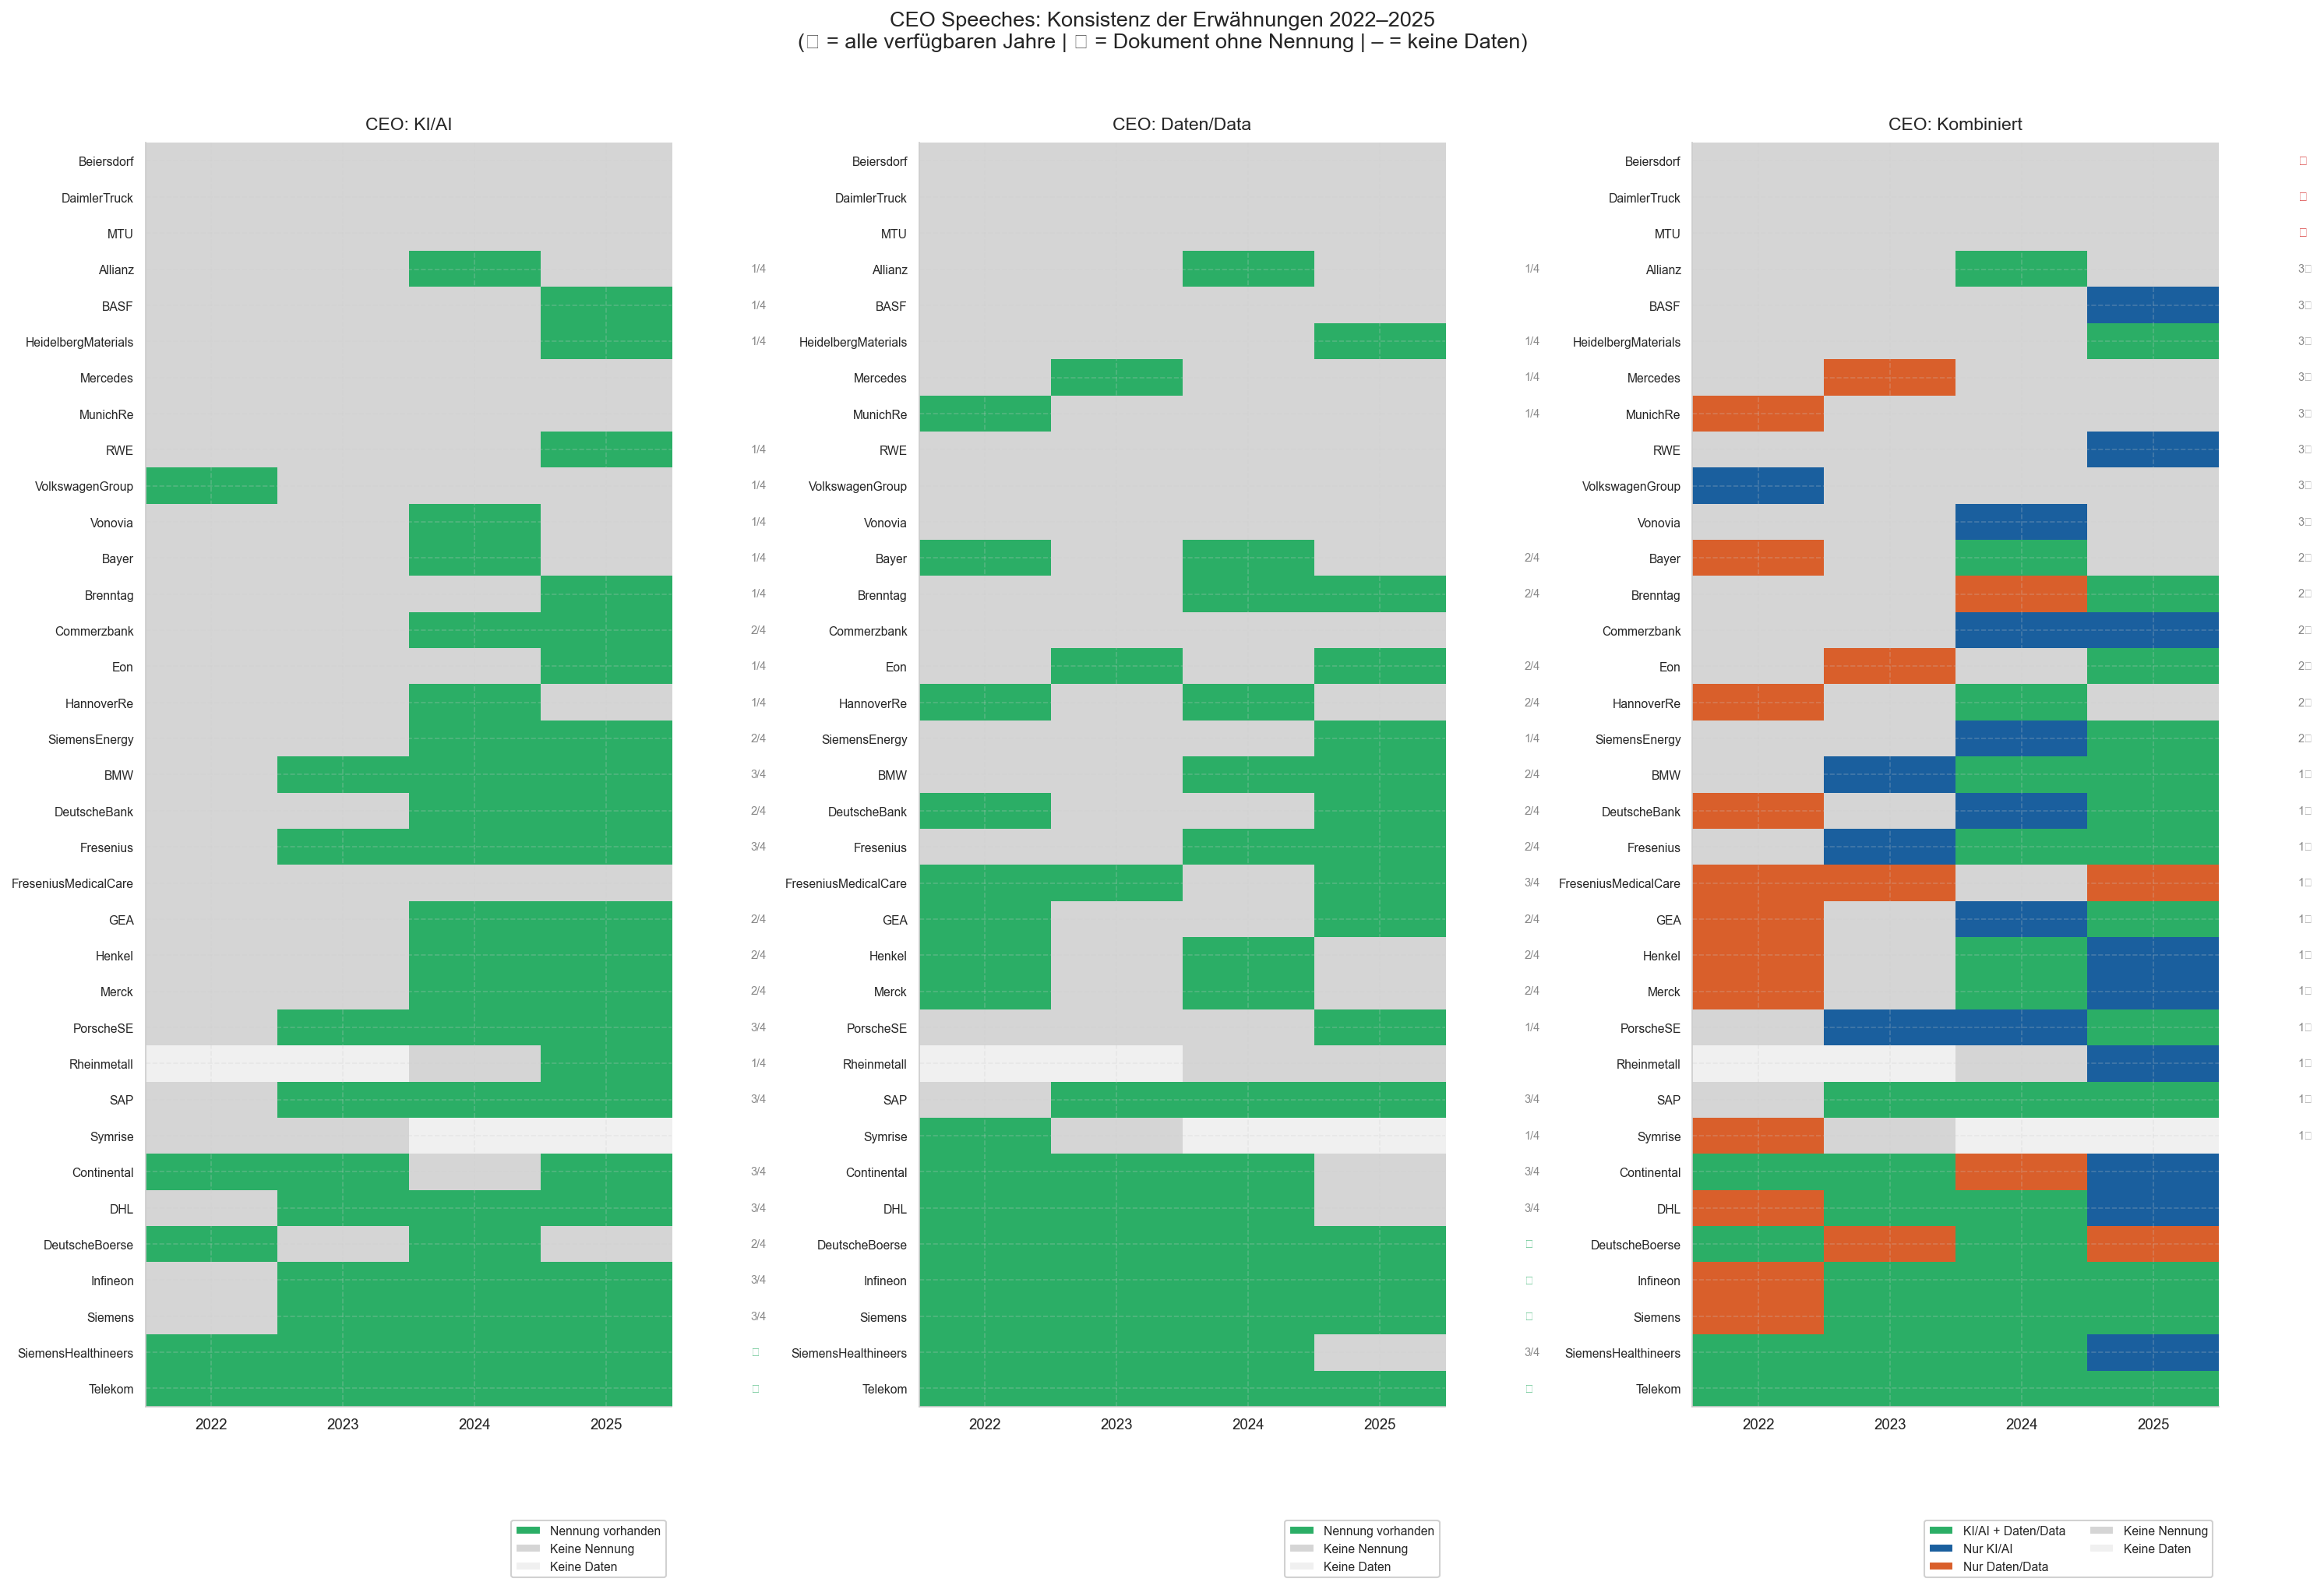

═══════════════════════════════════════════════════════
Firmen ohne jede Nennung in vorhandenen CEO-Docs:
  ✗ Beiersdorf  (Dokumente: [2022, 2023, 2024, 2025])
  ✗ DaimlerTruck  (Dokumente: [2022, 2023, 2024, 2025])
  ✗ MTU  (Dokumente: [2022, 2023, 2024, 2025])

Firmen mit KI/AI in allen verfügbaren Jahren (CEO):
  ★ SiemensHealthineers
  ★ Telekom

Firmen mit Daten/Data in allen verfügbaren Jahren (CEO):
  ★ DeutscheBoerse
  ★ Infineon
  ★ Siemens
  ★ Telekom


In [92]:
# ── KONSISTENZ CEO ONLY: Einzeln + Kombiniert ────────────────────────────────

ceo_freq = freq[freq['role'] == 'ceo']

# Welche Firma+Jahr Kombinationen haben überhaupt ein CEO-Dokument?
ceo_exists = set(zip(ceo_freq['company'], ceo_freq['year']))

cons_rows = []
for company in ceo_freq['company'].unique():
    co = ceo_freq[ceo_freq['company'] == company]
    for group in GROUPS:
        years_hit = set(
            co[(co['group'] == group) & (co['count_raw'] > 0)]['year'].tolist()
        ) & set(YEARS)
        years_with_doc = {y for y in YEARS if (company, y) in ceo_exists}
        cons_rows.append({
            'company':        company,
            'group':          group,
            'years_with_hit': sorted(years_hit),
            'years_with_doc': sorted(years_with_doc),
            'n_years':        len(years_hit),
            'all_4_years':    years_with_doc == set(YEARS) and len(years_hit) == len(YEARS),
        })

cons_df = pd.DataFrame(cons_rows)

combo_rows = []
for company in ceo_freq['company'].unique():
    co = ceo_freq[ceo_freq['company'] == company]
    years_either    = set()
    years_both      = set()
    years_ki        = set()
    years_data      = set()
    years_with_doc  = {y for y in YEARS if (company, y) in ceo_exists}

    for year in YEARS:
        yr       = co[co['year'] == year]
        has_ki   = (yr[yr['group'] == 'KI/AI']['count_raw'].sum()      > 0)
        has_data = (yr[yr['group'] == 'Daten/Data']['count_raw'].sum() > 0)
        if has_ki or has_data:
            years_either.add(year)
        if has_ki and has_data:
            years_both.add(year)
        if has_ki:
            years_ki.add(year)
        if has_data:
            years_data.add(year)

    combo_rows.append({
        'company':         company,
        'years_with_doc':  years_with_doc,
        'years_either':    sorted(years_either),
        'years_both':      sorted(years_both),
        'years_ki_only':   sorted(years_ki - years_data),
        'years_data_only': sorted(years_data - years_ki),
        'years_neither':   sorted(years_with_doc - years_either),
        'n_neither':       len(years_with_doc - years_either),
        'always_neither':  len(years_with_doc) > 0 and len(years_either) == 0,
        'no_data_at_all':  len(years_with_doc) == 0,
    })

combo_df = pd.DataFrame(combo_rows)

# Sortierung: Firmen ohne jede Nennung oben, dann nach n_neither, dann alphabetisch
sort_order = (combo_df
              .sort_values(['n_neither', 'company'], ascending=[False, True])
              ['company'].tolist())

n_companies = cons_df['company'].nunique()
fig, axes   = plt.subplots(1, 3, figsize=(20, max(5, n_companies * 0.32 + 2)), sharey=False)

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ── Plot A & B: Einzeln pro Gruppe ───────────────────────────────────────────
for ax, group in zip(axes[:2], GROUPS):
    sub = (cons_df[cons_df['group'] == group]
           .set_index('company')
           .reindex(sort_order)
           .reset_index())

    matrix = []
    for _, row in sub.iterrows():
        year_row = []
        for year in YEARS:
            if (row['company'], year) not in ceo_exists:
                year_row.append(-1)   # kein Dokument
            elif year in row['years_with_hit']:
                year_row.append(1)    # Nennung vorhanden
            else:
                year_row.append(0)    # Dokument vorhanden, keine Nennung
        matrix.append(year_row)

    mat = np.array(matrix)
    cmap_single = ListedColormap(['#F0F0F0', '#D5D5D5', '#2BAE66'])
    ax.imshow(mat, cmap=cmap_single, aspect='auto', vmin=-1, vmax=1)

    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels(YEARS, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['company'], fontsize=7.5)
    ax.set_title(f'CEO: {group}', fontsize=11, pad=8)

    for i, (_, row) in enumerate(sub.iterrows()):
        if row['all_4_years']:
            ax.text(len(YEARS) + 0.1, i, '★',
                    va='center', fontsize=7.5, color='#2BAE66')
        elif row['n_years'] > 0:
            ax.text(len(YEARS) + 0.1, i, f"{row['n_years']}/4",
                    va='center', fontsize=7, color='#888')

    legend_single = [
        Patch(facecolor='#2BAE66', label='Nennung vorhanden'),
        Patch(facecolor='#D5D5D5', label='Keine Nennung'),
        Patch(facecolor='#F0F0F0', label='Keine Daten'),
    ]
    ax.legend(handles=legend_single, fontsize=7.5,
              loc='lower right', bbox_to_anchor=(1.0, -0.14),
              ncol=1, framealpha=0.9)

# ── Plot C: Kombiniert ────────────────────────────────────────────────────────
ax = axes[2]
combo_sorted = (combo_df
                .set_index('company')
                .reindex(sort_order)
                .reset_index())

# Kategorien: -1=keine Daten, 0=keine Nennung, 1=nur Daten, 2=nur KI, 3=beide
cat_matrix = []
for _, row in combo_sorted.iterrows():
    year_row = []
    for year in YEARS:
        if (row['company'], year) not in ceo_exists:
            year_row.append(-1)
        elif year in row['years_both']:
            year_row.append(3)
        elif year in row['years_ki_only']:
            year_row.append(2)
        elif year in row['years_data_only']:
            year_row.append(1)
        else:
            year_row.append(0)
    cat_matrix.append(year_row)

mat_combo   = np.array(cat_matrix)
cmap_combo  = ListedColormap(['#F0F0F0', '#D5D5D5', C['Daten/Data'], C['KI/AI'], '#2BAE66'])
ax.imshow(mat_combo, cmap=cmap_combo, aspect='auto', vmin=-1, vmax=3)

ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=9)
ax.set_yticks(range(len(combo_sorted)))
ax.set_yticklabels(combo_sorted['company'], fontsize=7.5)
ax.set_title('CEO: Kombiniert', fontsize=11, pad=8)

legend_combo = [
    Patch(facecolor='#2BAE66',       label='KI/AI + Daten/Data'),
    Patch(facecolor=C['KI/AI'],      label='Nur KI/AI'),
    Patch(facecolor=C['Daten/Data'], label='Nur Daten/Data'),
    Patch(facecolor='#D5D5D5',       label='Keine Nennung'),
    Patch(facecolor='#F0F0F0',       label='Keine Daten'),
]
ax.legend(handles=legend_combo, fontsize=7.5,
          loc='lower right', bbox_to_anchor=(1.0, -0.14),
          ncol=2, framealpha=0.9)

for i, (_, row) in enumerate(combo_sorted.iterrows()):
    if row['no_data_at_all']:
        ax.text(len(YEARS) + 0.1, i, '–',
                va='center', fontsize=8, color='#BBB')
    elif row['always_neither']:
        ax.text(len(YEARS) + 0.1, i, '✗',
                va='center', fontsize=8, color='#C00')
    elif row['n_neither'] > 0:
        ax.text(len(YEARS) + 0.1, i, f"{row['n_neither']}✗",
                va='center', fontsize=7, color='#888')

fig.suptitle('CEO Speeches: Konsistenz der Erwähnungen 2022–2025\n'
             '(★ = alle verfügbaren Jahre | ✗ = Dokument ohne Nennung | – = keine Daten)',
             fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_konsistenz_ceo_kombiniert.png', bbox_inches='tight')
plt.show()

# ── Textausgaben ──────────────────────────────────────────────────────────────
print('═' * 55)
print('Firmen ohne jede Nennung in vorhandenen CEO-Docs:')
for _, row in combo_df[combo_df['always_neither']].iterrows():
    print(f'  ✗ {row["company"]}  (Dokumente: {sorted(row["years_with_doc"])})')

print(f'\nFirmen mit KI/AI in allen verfügbaren Jahren (CEO):')
for _, row in cons_df[(cons_df['group'] == 'KI/AI') & cons_df['all_4_years']].iterrows():
    print(f'  ★ {row["company"]}')

print(f'\nFirmen mit Daten/Data in allen verfügbaren Jahren (CEO):')
for _, row in cons_df[(cons_df['group'] == 'Daten/Data') & cons_df['all_4_years']].iterrows():
    print(f'  ★ {row["company"]}')

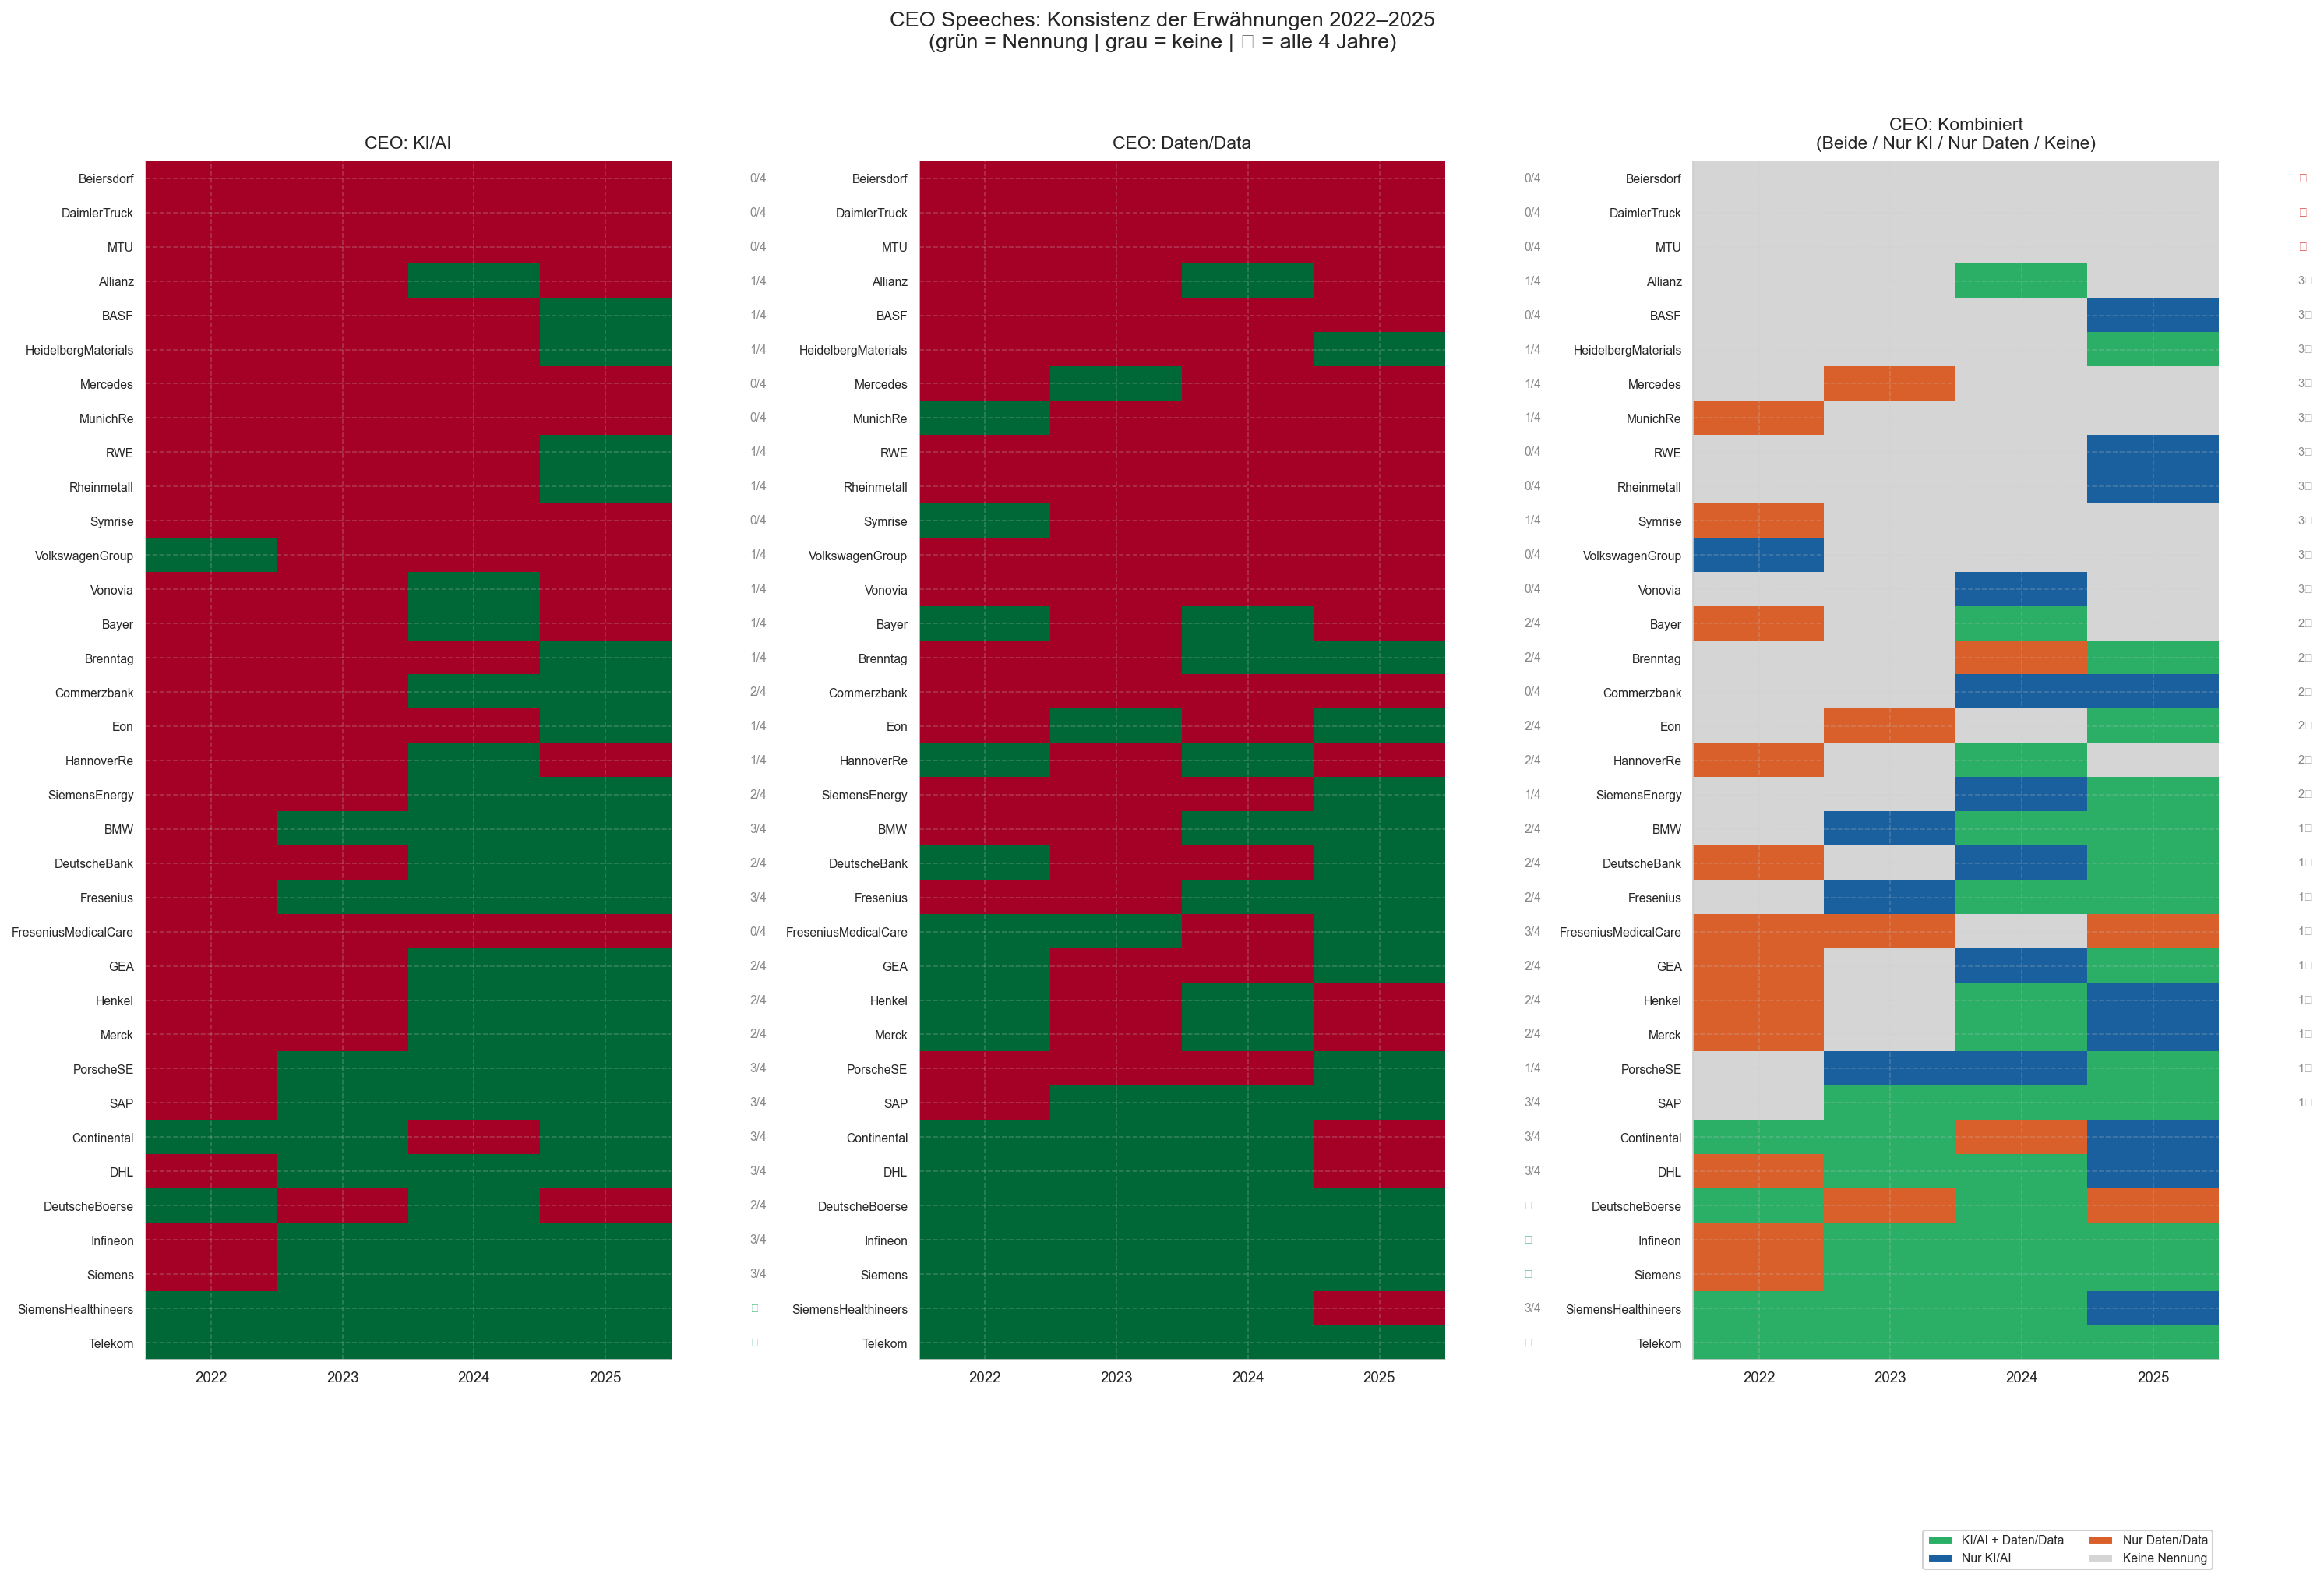

═══════════════════════════════════════════════════════
Firmen ohne jede Nennung (CEO, alle 4 Jahre):
  ✗ Beiersdorf
  ✗ DaimlerTruck
  ✗ MTU

Firmen mit KI/AI in allen 4 Jahren (CEO):
  ★ SiemensHealthineers
  ★ Telekom

Firmen mit Daten/Data in allen 4 Jahren (CEO):
  ★ DeutscheBoerse
  ★ Infineon
  ★ Siemens
  ★ Telekom


In [93]:
# ── KONSISTENZ CEO ONLY: Einzeln + Kombiniert ────────────────────────────────

ceo_freq = freq[freq['role'] == 'ceo']

cons_rows = []
for company in ceo_freq['company'].unique():
    co = ceo_freq[ceo_freq['company'] == company]
    for group in GROUPS:
        years_hit = set(
            co[(co['group'] == group) & (co['count_raw'] > 0)]['year'].tolist()
        ) & set(YEARS)
        cons_rows.append({
            'company': company,
            'group':   group,
            'years_with_hit': sorted(years_hit),
            'n_years':        len(years_hit),
            'all_4_years':    len(years_hit) == len(YEARS),
        })

cons_df = pd.DataFrame(cons_rows)

# ── Kombiniert: keine der beiden Gruppen ──
combo_rows = []
for company in ceo_freq['company'].unique():
    co = ceo_freq[ceo_freq['company'] == company]
    years_either = set()
    years_both   = set()
    years_ki     = set()
    years_data   = set()
    for year in YEARS:
        yr = co[co['year'] == year]
        has_ki   = (yr[yr['group'] == 'KI/AI']['count_raw'].sum()     > 0)
        has_data = (yr[yr['group'] == 'Daten/Data']['count_raw'].sum() > 0)
        if has_ki or has_data:
            years_either.add(year)
        if has_ki and has_data:
            years_both.add(year)
        if has_ki:
            years_ki.add(year)
        if has_data:
            years_data.add(year)
    combo_rows.append({
        'company':          company,
        'years_either':     sorted(years_either),
        'years_both':       sorted(years_both),
        'years_ki_only':    sorted(years_ki - years_data),
        'years_data_only':  sorted(years_data - years_ki),
        'years_neither':    sorted(set(YEARS) - years_either),
        'n_neither':        len(set(YEARS) - years_either),
        'always_neither':   len(years_either) == 0,
    })

combo_df = pd.DataFrame(combo_rows)

n_companies = cons_df['company'].nunique()
fig, axes = plt.subplots(1, 3, figsize=(20, max(5, n_companies * 0.32 + 2)), sharey=False)

# Einheitliche Firmensortierung über alle drei Plots:
# sortiert nach: n_neither DESC, dann alphabetisch
sort_order = (combo_df
              .sort_values(['n_neither', 'company'], ascending=[False, True])
              ['company'].tolist())

# ── Plot A & B: Einzeln pro Gruppe ──
for ax, group in zip(axes[:2], GROUPS):
    sub = cons_df[cons_df['group'] == group].set_index('company').reindex(sort_order).reset_index()

    matrix = [[1 if y in row['years_with_hit'] else 0 for y in YEARS]
               for _, row in sub.iterrows()]
    mat = np.array(matrix)

    ax.imshow(mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels(YEARS, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['company'], fontsize=7.5)
    ax.set_title(f'CEO: {group}', fontsize=11, pad=8)

    for i, (_, row) in enumerate(sub.iterrows()):
        marker = '★' if row['all_4_years'] else f"{row['n_years']}/4"
        color  = '#2BAE66' if row['all_4_years'] else '#888'
        ax.text(len(YEARS) + 0.1, i, marker, va='center', fontsize=7.5, color=color)

# ── Plot C: Kombiniert — Kategorie pro Jahr ──
ax = axes[2]
combo_sorted = combo_df.set_index('company').reindex(sort_order).reset_index()

# 4 Kategorien pro Zelle: both=3, ki_only=2, data_only=1, neither=0
cat_matrix = []
for _, row in combo_sorted.iterrows():
    year_row = []
    for year in YEARS:
        if year in row['years_both']:
            year_row.append(3)
        elif year in row['years_ki_only']:
            year_row.append(2)
        elif year in row['years_data_only']:
            year_row.append(1)
        else:
            year_row.append(0)
    cat_matrix.append(year_row)

mat_combo = np.array(cat_matrix)

from matplotlib.colors import ListedColormap
cmap_combo = ListedColormap(['#D5D5D5', C['Daten/Data'], C['KI/AI'], '#2BAE66'])
ax.imshow(mat_combo, cmap=cmap_combo, aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=9)
ax.set_yticks(range(len(combo_sorted)))
ax.set_yticklabels(combo_sorted['company'], fontsize=7.5)
ax.set_title('CEO: Kombiniert\n(Beide / Nur KI / Nur Daten / Keine)', fontsize=11, pad=8)

# Legende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2BAE66',      label='KI/AI + Daten/Data'),
    Patch(facecolor=C['KI/AI'],     label='Nur KI/AI'),
    Patch(facecolor=C['Daten/Data'],label='Nur Daten/Data'),
    Patch(facecolor='#D5D5D5',      label='Keine Nennung'),
]
ax.legend(handles=legend_elements, fontsize=7.5,
          loc='lower right', bbox_to_anchor=(1.0, -0.18),
          ncol=2, framealpha=0.9)

# Annotation rechts: Anzahl Jahre ohne jede Nennung
for i, (_, row) in enumerate(combo_sorted.iterrows()):
    if row['always_neither']:
        ax.text(len(YEARS) + 0.1, i, '✗', va='center', fontsize=8, color='#C00')
    elif row['n_neither'] > 0:
        ax.text(len(YEARS) + 0.1, i, f"{row['n_neither']}✗",
                va='center', fontsize=7, color='#888')

fig.suptitle('CEO Speeches: Konsistenz der Erwähnungen 2022–2025\n'
             '(grün = Nennung | grau = keine | ★ = alle 4 Jahre)',
             fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_konsistenz_ceo_kombiniert_old.png', bbox_inches='tight')
plt.show()

# Textausgaben
print('═' * 55)
print('Firmen ohne jede Nennung (CEO, alle 4 Jahre):')
always_none = combo_df[combo_df['always_neither']]['company'].tolist()
for c in always_none:
    print(f'  ✗ {c}')

print(f'\nFirmen mit KI/AI in allen 4 Jahren (CEO):')
for _, row in cons_df[(cons_df['group'] == 'KI/AI') & cons_df['all_4_years']].iterrows():
    print(f'  ★ {row["company"]}')

print(f'\nFirmen mit Daten/Data in allen 4 Jahren (CEO):')
for _, row in cons_df[(cons_df['group'] == 'Daten/Data') & cons_df['all_4_years']].iterrows():
    print(f'  ★ {row["company"]}')

## Plot 10 - Branche (nur CEO)

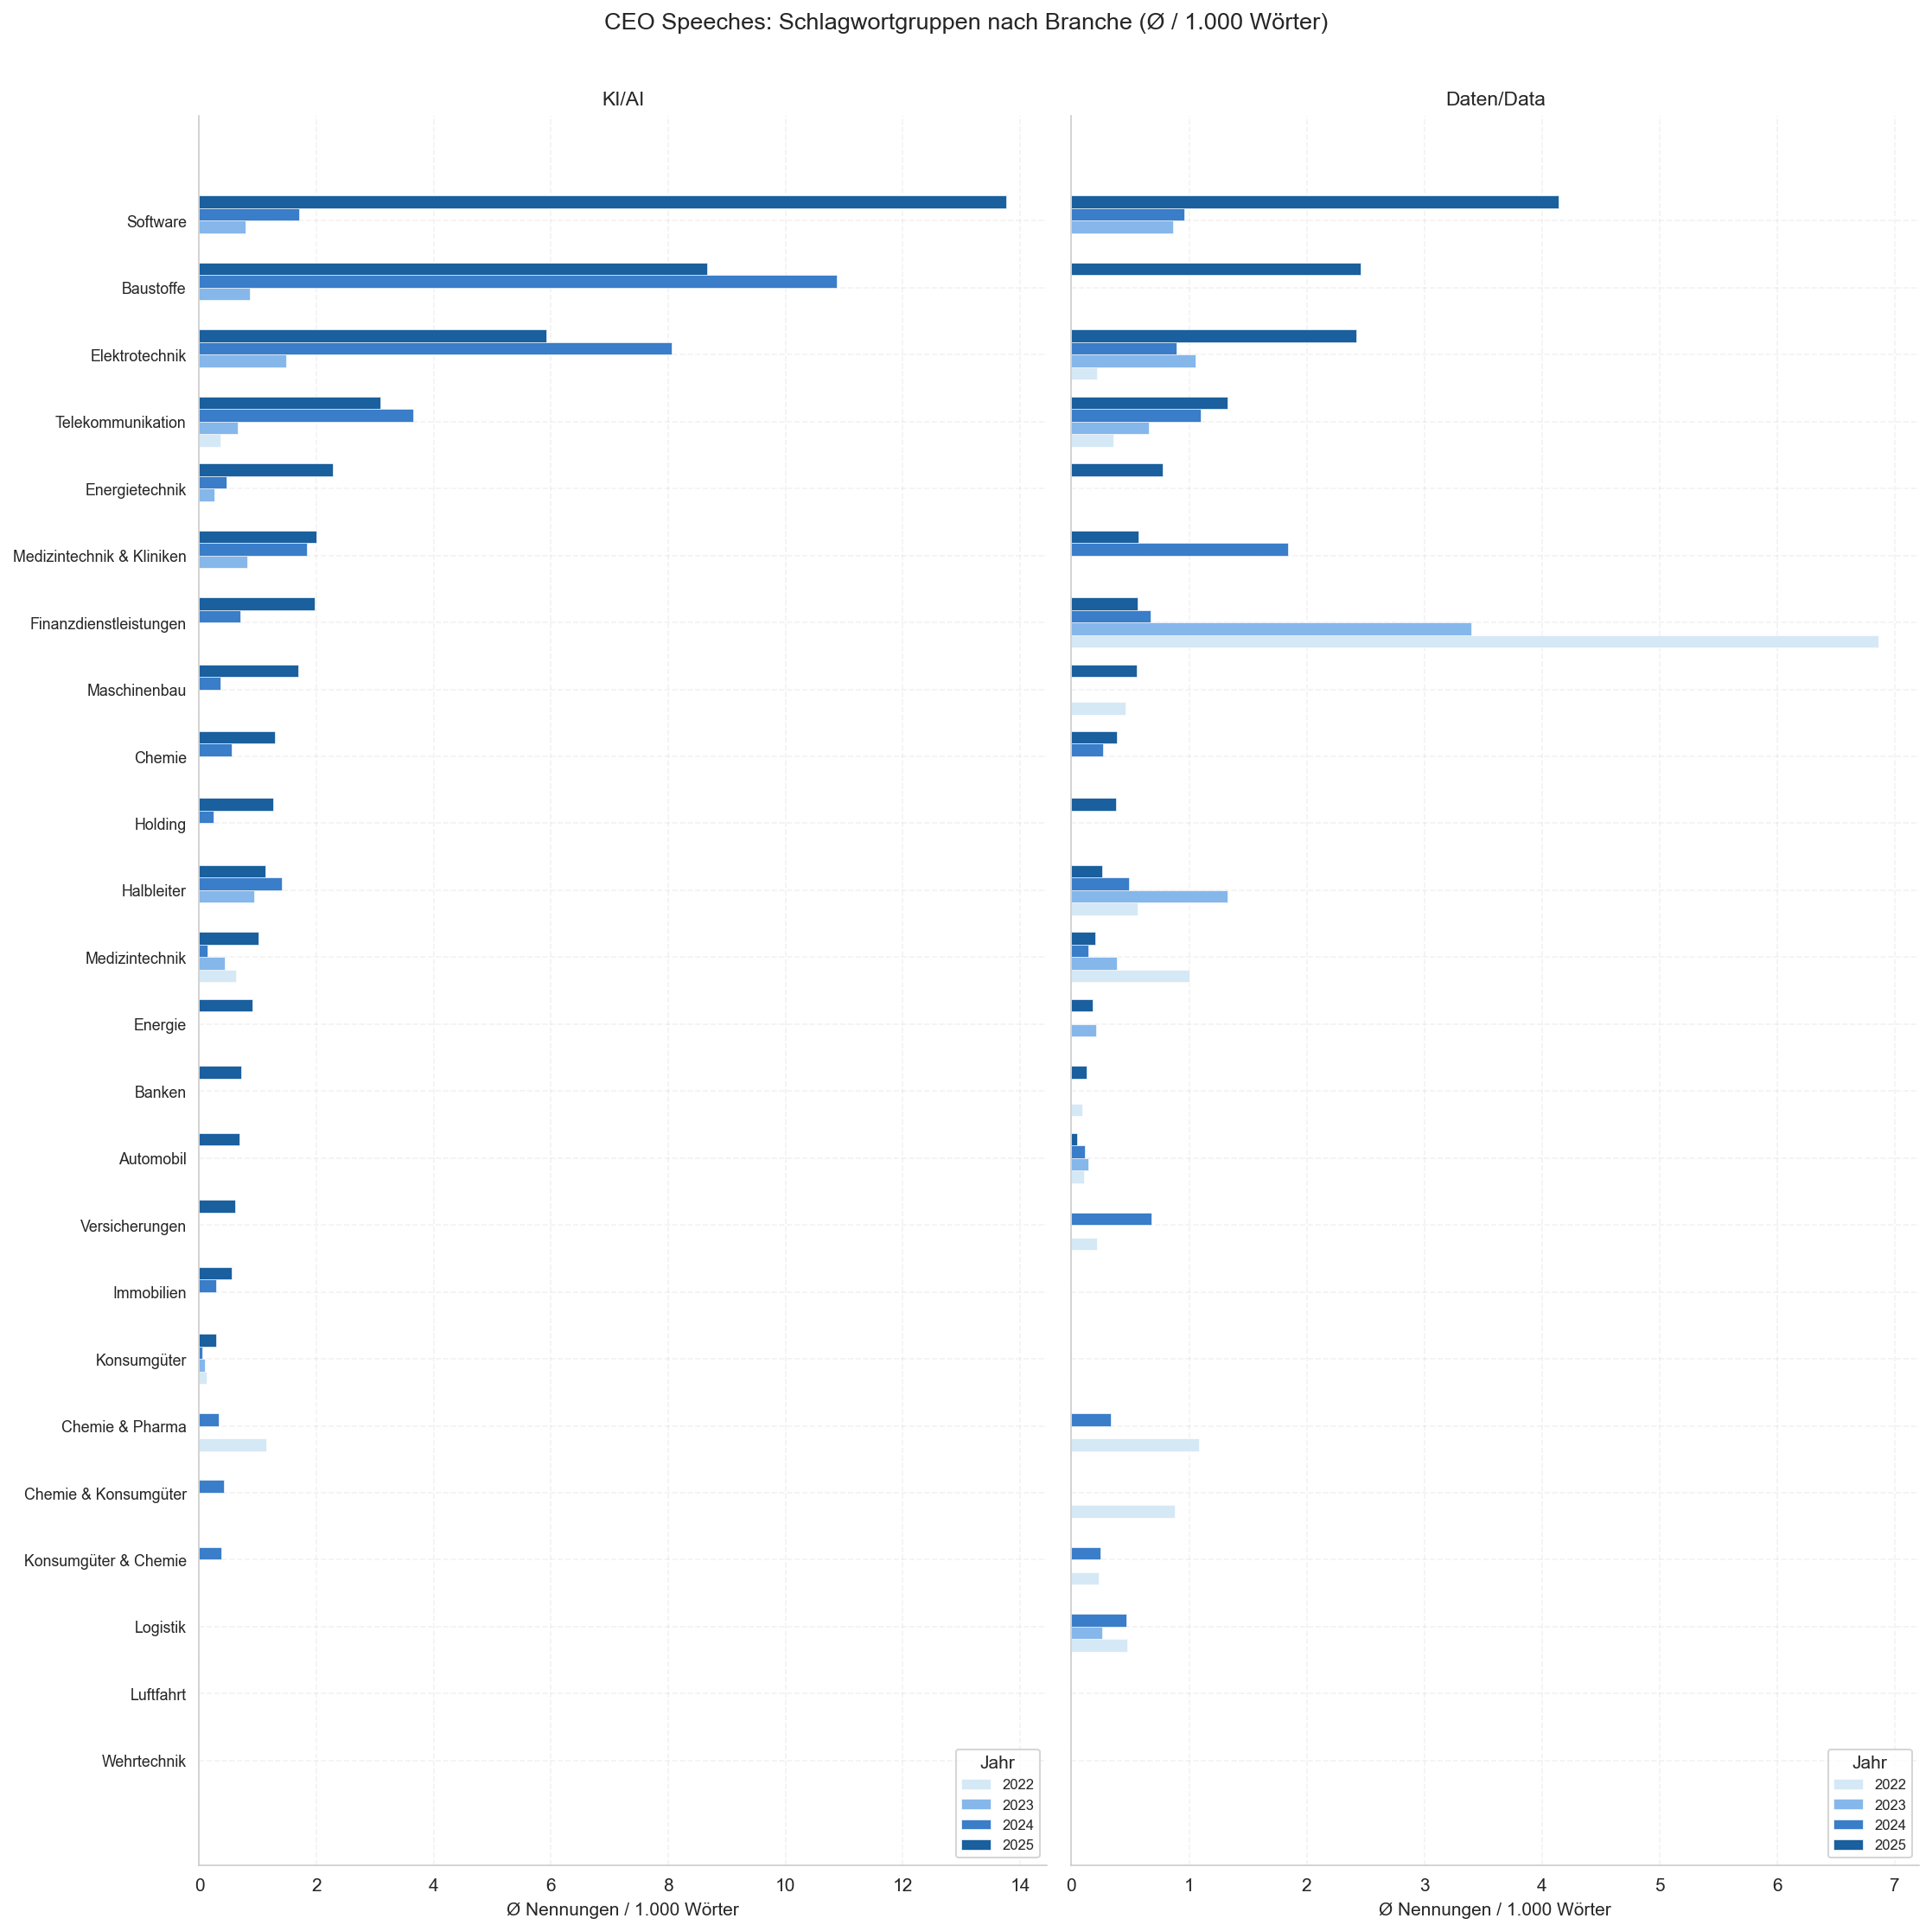

In [86]:
# ── CEO: Schlagwortgruppen nach Branche ──────────────────────────────────────

sector_df = freq[freq['role'] == 'ceo'].groupby(
    ['sector', 'year', 'group']
).agg(
    norm_mean=('count_norm', 'mean'),
    raw_sum=('count_raw',   'sum'),
).reset_index()

sectors = sorted(sector_df['sector'].unique())
n_sectors = len(sectors)

fig, axes = plt.subplots(
    1, 2, figsize=(15, max(5, n_sectors * 0.55 + 1.5)), sharey=True
)
fig.suptitle('CEO Speeches: Schlagwortgruppen nach Branche (Ø / 1.000 Wörter)',
             fontsize=13, y=1.01)

for ax, group in zip(axes, GROUPS):
    pivot = sector_df[sector_df['group'] == group].pivot_table(
        index='sector', columns='year', values='norm_mean', fill_value=0
    ).reindex(columns=YEARS, fill_value=0)
    pivot = pivot.sort_values(YEARS[-1], ascending=True)

    year_colors = ['#D5E8F5', '#85B7EB', '#3A7DC9', '#1A5F9E']
    x = np.arange(len(pivot))
    n_years = len(YEARS)
    total_w = 0.75
    w = total_w / n_years

    for i, (year, color) in enumerate(zip(YEARS, year_colors)):
        offset = (i - n_years / 2 + 0.5) * w
        vals = pivot[year].values
        bars = ax.barh(x + offset, vals, w,
                       label=str(year), color=color,
                       edgecolor='white', linewidth=0.3)

    ax.set_yticks(x)
    ax.set_yticklabels(pivot.index, fontsize=8.5)
    ax.set_xlabel('Ø Nennungen / 1.000 Wörter', fontsize=10)
    ax.set_title(group, fontsize=11)
    ax.legend(title='Jahr', fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_branchen_ceo.png', bbox_inches='tight')
plt.show()

## Final

In [80]:
print('\n✓ Alle Plots gespeichert in:', FIG_DIR)
print('✓ Tabellen gespeichert in:  ', REP_DIR)


✓ Alle Plots gespeichert in: /Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis/outputs/figures/cross_company
✓ Tabellen gespeichert in:   /Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis/outputs/reports
